# ME-XBAL — SemEval 2025 Task 11 (Revised Pipeline)

This notebook is a thoroughly improved version. Run cells from top to bottom.

**Improvements compared to the previous version**

| # | Improvement | Plan Item |
|---|---|---|
| 1 | `MultilabelStratifiedShuffleSplit` replaces `MultilabelStratifiedKFold` — split proportions now strictly follow the configuration (fixing the 80/16/4 bug), plus automated assertions | P1.1 |
| 2 | Stable UIDs per row; all partitions for every seed are exported for reproducibility | P1.1 / P3.3 |
| 3 | Embeddings are extracted ONCE for the entire dataset then sliced per split — making multi-seed experiments computationally cheap | Efficiency |
| 4 | **10 seeds**, mean ± std, 95% CI, and paired Wilcoxon tests | P2.1 |
| 5 | Single-factor ablation A0→A6 (one component changes per row) | P2.3 |
| 6 | SHAP faithfulness tests: deletion / insertion + AOPC vs random token ordering | P2.2 |
| 7 | Timing is separated by boundary: embedding, training, threshold search, inference, SHAP | P2.4 |
| 8 | Full fine-tuned XLM-R baseline (optional) as a comparison outside frozen-embeddings | P2.5 |
| 9 | All images 600 dpi + vector PDF versions; all tables exported to CSV from a single source | P1.4 / P3.2 |

All data-dependent transformations (scaler, PCA, class weight, threshold) are fitted **only on train/validation**. The test set is never touched until the final evaluation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration & Imports

In [2]:
# ============================================================
# GLOBAL CONFIGURATION
# Change only in this cell; other cells read constants from here.
# ============================================================
import os, sys, re, time, json, random, subprocess, warnings
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy import stats
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

try:
    from iterstrat.ml_stratifiers import (MultilabelStratifiedShuffleSplit,
                                          MultilabelStratifiedKFold)
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "iterative-stratification"], check=False)
    from iterstrat.ml_stratifiers import (MultilabelStratifiedShuffleSplit,
                                          MultilabelStratifiedKFold)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
DATA_ROOT = "/content/drive/MyDrive/INASS Project/dataset/SemEval2025"
OUT_DIR   = "/content/drive/MyDrive/INASS Project/outputs/Semeval"
FIG_DIR   = os.path.join(OUT_DIR, "figures")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
CACHE_DIR = os.path.join(OUT_DIR, "cache")
for d in (OUT_DIR, FIG_DIR, SPLIT_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

# ------------------------------------------------------------
# EXPERIMENT PROTOCOL
# ------------------------------------------------------------
SEEDS        = [42, 7, 13, 77, 101, 202, 303, 404, 505, 606]   # 10 seeds -> Wilcoxon feasible
SEED_PRIMARY = 42            # seed for SHAP, confusion matrix, timing, figures
VAL_FRAC     = 0.15          # threshold tuned here
TEST_FRAC    = 0.20          # never touched until final evaluation
# train = 1 - VAL_FRAC - TEST_FRAC = 0.65

EMOTION_COLS = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]
LANGS        = ["sun", "jav", "ind"]
LANG_LABEL   = {"sun": "Sundanese", "jav": "Javanese", "ind": "Indonesian"}

# ------------------------------------------------------------
# ENCODERS
# ------------------------------------------------------------
XLMR_NAME     = "xlm-roberta-base"
INDOBERT_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN       = 128
BATCH_SIZE    = 32
POOLING       = "masked_mean"   # consistent for ALL encoders & SHAP

# ------------------------------------------------------------
# ADDITIONAL ANALYSES (Turn off for fast run)
# ------------------------------------------------------------
RUN_ABLATION   = True
RUN_FAITHFUL   = True    # SHAP deletion/insertion test (~5-10 mins)
RUN_TIMING     = True
RUN_FINETUNE   = True    # Baseline fine-tuned XLM-R (~10-15 mins, requires GPU)
FT_SEEDS       = SEEDS        # 10 seed: dengan 3 seed, p minimum Wilcoxon = 0.25 (mustahil signifikan)
FT_MAX_EPOCHS  = 8            # early stopping menurunkan variansi fine-tuning (std lama 0.059-0.072)
FT_PATIENCE    = 3
N_FAITHFUL     = 30      # sample size for AOPC test
SHAP_MAX_EVALS = 300

# ------------------------------------------------------------
# HYPERPARAMETERS
# ------------------------------------------------------------
XGB_PARAMS = dict(
    max_depth=3, min_child_weight=5, learning_rate=0.05, n_estimators=200,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.5,
    objective="binary:logistic", eval_metric="logloss", verbosity=0, n_jobs=-1,
)
THRESHOLD_MIN   = 0.15   # batas bawah grid — mencegah threshold degeneratif "prediksi semua positif"
THRESHOLD_MAX   = 0.85
THRESHOLD_STEP  = 0.01
MIN_PRECISION   = 0.20   # precision minimum di VALIDATION agar sebuah threshold dianggap sah
MAX_PPR_RATIO   = 3.0    # prediksi positif maksimum = 3x base rate kelas (anti "prediksi semua positif")

# ------------------------------------------------------------
# NESTED CROSS-VALIDATION untuk pemilihan threshold
#
# Validation split per bahasa hanya berisi 22-23 sampel dengan 2-3 positif untuk
# kelas langka. Memilih threshold dari data sesedikit itu tidak stabil, dan itulah
# sebab beberapa kelas berakhir F1 = 0. Dengan nested CV, threshold dipilih dari
# probabilitas out-of-fold atas SELURUH development set (train + validation),
# sehingga jumlah sampel untuk kalibrasi naik 5-6x.
#
# Test set tetap tidak pernah disentuh. Ini persis "nested cross-validation"
# yang diminta Reviewer 2 #3.
# ------------------------------------------------------------
USE_NESTED_CV   = True
NESTED_CV_FOLDS = 5
TIE_TOLERANCE   = 0.005  # F1 dalam rentang ini dianggap seri -> pilih threshold paling konservatif
THRESHOLD_GRID  = np.arange(THRESHOLD_MIN, THRESHOLD_MAX + 1e-9, THRESHOLD_STEP)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

plt.rcParams.update({"font.size": 11, "savefig.dpi": 600, "figure.dpi": 110})

def savefig(fig, name):
    """Save each figure in 600 dpi PNG AND vector PDF (P3.2)."""
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=600, bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"), format="pdf", bbox_inches="tight")

print("Device        :", device)
print("Seeds         :", SEEDS)
print(f"Split fraction: train {1-VAL_FRAC-TEST_FRAC:.2f} / val {VAL_FRAC:.2f} / test {TEST_FRAC:.2f}")

Device        : cuda
Seeds         : [42, 7, 13, 77, 101, 202, 303, 404, 505, 606]
Split fraction: train 0.65 / val 0.15 / test 0.20


## 2. Data, Stable UID, and Three-way Split

The core improvement is in `multilabel_split()`. The old version used `MultilabelStratifiedKFold(n_splits=5)` which structurally could only produce ~20% holdout, and slicing it did not allow for flexible ratios. This led to a hidden 80/16/4 split instead of the requested 70/10/20.

`MultilabelStratifiedShuffleSplit` accepts any `test_size`. Assertions below ensure similar bugs never pass silently again.

In [3]:
# ============================================================
# LOAD DATA + STABLE UID
# UID is assigned BEFORE any split, so partitions can be
# exactly reconstructed by others from the exported CSV files.
# ============================================================
df_sun_train_raw = pd.read_csv(f"{DATA_ROOT}/track_a/train/sun.csv")
df_sun_dev_raw   = pd.read_csv(f"{DATA_ROOT}/track_a/dev/sun.csv")
df_sun_all       = pd.concat([df_sun_train_raw, df_sun_dev_raw], ignore_index=True)

df_jav_all = pd.read_csv(f"{DATA_ROOT}/track_c/dev/jav.csv")
df_ind_all = pd.read_csv(f"{DATA_ROOT}/track_c/dev/ind.csv")

DATA = {"sun": df_sun_all, "jav": df_jav_all, "ind": df_ind_all}

for lang, df in DATA.items():
    df.reset_index(drop=True, inplace=True)
    df["uid"] = [f"{lang}_{i:05d}" for i in range(len(df))]
    missing = [c for c in EMOTION_COLS + ["text"] if c not in df.columns]
    assert not missing, f"{lang}: missing columns {missing}"

Y = {lang: DATA[lang][EMOTION_COLS].values.astype(int) for lang in LANGS}

print("Dataset size (entire data, before split):")
for lang in LANGS:
    print(f"  {LANG_LABEL[lang]:<12}: {len(DATA[lang])} samples")


# ============================================================
# THREE-WAY SPLIT — MAIN FIX
# ============================================================
def multilabel_split(y, test_size, seed):
    """Return (idx_a, idx_b) with |idx_b| ~= test_size * n, stratified multi-label.

    Uses MultilabelStratifiedShuffleSplit which ACCEPTS arbitrary test_size.
    Fallback to random split only if stratification fails (labels too sparse).
    """
    n = len(y)
    try:
        msss = MultilabelStratifiedShuffleSplit(
            n_splits=1, test_size=test_size, random_state=seed)
        idx_a, idx_b = next(msss.split(np.zeros(n), y))
    except Exception as e:
        print(f"    [multilabel_split] fallback random split ({type(e).__name__}: {e})")
        idx_a, idx_b = train_test_split(np.arange(n), test_size=test_size, random_state=seed)
    return np.sort(idx_a), np.sort(idx_b)


def three_way_split(y, seed, val_frac=VAL_FRAC, test_frac=TEST_FRAC):
    """train / val / test immutable. val & test are never used for fitting."""
    hold_frac = val_frac + test_frac
    idx_train, idx_hold = multilabel_split(y, hold_frac, seed)
    rel_test = test_frac / hold_frac
    sub_val, sub_test = multilabel_split(y[idx_hold], rel_test, seed)
    return idx_train, idx_hold[sub_val], idx_hold[sub_test]


# ------------------------------------------------------------
# Build all splits upfront, then VERIFY proportions
# ------------------------------------------------------------
SPLITS = {}
rows = []
for seed in SEEDS:
    for lang in LANGS:
        tr, va, te = three_way_split(Y[lang], seed)
        SPLITS[(lang, seed)] = (tr, va, te)

        n = len(DATA[lang])
        assert len(set(tr) & set(va)) == 0 and len(set(tr) & set(te)) == 0 \
               and len(set(va) & set(te)) == 0, f"{lang}/{seed}: overlapping partitions"
        assert len(tr) + len(va) + len(te) == n, f"{lang}/{seed}: missing samples"
        assert abs(len(te)/n - TEST_FRAC) < 0.04, \
               f"{lang}/{seed}: test frac {len(te)/n:.3f} != {TEST_FRAC}"
        assert abs(len(va)/n - VAL_FRAC) < 0.04, \
               f"{lang}/{seed}: val frac {len(va)/n:.3f} != {VAL_FRAC}"

        uids = DATA[lang]["uid"].values
        for split_name, idx in [("train", tr), ("val", va), ("test", te)]:
            for u in uids[idx]:
                rows.append({"lang": lang, "seed": seed, "split": split_name, "uid": u})

split_manifest = pd.DataFrame(rows)
split_manifest.to_csv(os.path.join(SPLIT_DIR, "split_manifest_all_seeds.csv"), index=False)

print("\nAll split proportion assertions PASSED.\n")
print(f"Split size example (seed={SEED_PRIMARY}):")
print(f"{'Language':<12} {'Train':>7} {'Val':>7} {'Test':>7}   {'actual proportions':>24}")
print("-" * 62)
for lang in LANGS:
    tr, va, te = SPLITS[(lang, SEED_PRIMARY)]
    n = len(DATA[lang])
    print(f"{LANG_LABEL[lang]:<12} {len(tr):>7} {len(va):>7} {len(te):>7}   "
          f"{len(tr)/n:>7.2f} /{len(va)/n:>6.2f} /{len(te)/n:>6.2f}")
print(f"\nPartition manifest saved: {SPLIT_DIR}/split_manifest_all_seeds.csv "
      f"({len(split_manifest)} rows)")

# ============================================================
# EKSPOR UKURAN PARTISI — untuk Tabel 3 manuskrip
#
# Angka train/validation di manuskrip sebelumnya DITURUNKAN dari n_test dengan
# proporsi nominal, bukan dibaca dari data. Pembulatan MultilabelStratified-
# ShuffleSplit bisa menggeser 1-2 sampel, dan pada subset Javanese (n=155)
# pergeseran itu terlihat. Ekspor ini menggantikan angka turunan tersebut.
# ============================================================
rows_sz = []
for seed in SEEDS:
    for lang in LANGS:
        tr, va, te = SPLITS[(lang, seed)]
        rows_sz.append({"language": LANG_LABEL[lang], "seed": seed,
                        "total": len(DATA[lang]),
                        "train": len(tr), "validation": len(va), "test": len(te)})
df_sizes = pd.DataFrame(rows_sz)
df_sizes.to_csv(os.path.join(OUT_DIR, "table_split_sizes_all_seeds.csv"), index=False)

primary_sizes = df_sizes[df_sizes["seed"] == SEED_PRIMARY].drop(columns="seed")
primary_sizes.loc[len(primary_sizes)] = ["TOTAL", primary_sizes["total"].sum(),
                                         primary_sizes["train"].sum(),
                                         primary_sizes["validation"].sum(),
                                         primary_sizes["test"].sum()]
primary_sizes.to_csv(os.path.join(OUT_DIR, "table_split_sizes_primary.csv"), index=False)

print("\n" + "=" * 66)
print(f"UKURAN PARTISI (seed={SEED_PRIMARY}) — SALIN ANGKA INI KE TABEL 3")
print("=" * 66)
print(primary_sizes.to_string(index=False))

var_sz = df_sizes.groupby("language")[["train", "validation", "test"]].nunique()
if (var_sz > 1).any().any():
    print("\nCatatan: ukuran partisi bervariasi antar seed (pembulatan stratifikasi).")
    print("Gunakan angka seed utama di tabel dan sebut rentangnya di teks bila perlu.")
    print(df_sizes.groupby("language")[["train", "validation", "test"]]
          .agg(["min", "max"]).to_string())


Dataset size (entire data, before split):
  Sundanese   : 1123 samples
  Javanese    : 151 samples
  Indonesian  : 156 samples

All split proportion assertions PASSED.

Split size example (seed=42):
Language       Train     Val    Test         actual proportions
--------------------------------------------------------------
Sundanese        729     168     226      0.65 /  0.15 /  0.20
Javanese          98      22      31      0.65 /  0.15 /  0.21
Indonesian       100      23      33      0.64 /  0.15 /  0.21

Partition manifest saved: /content/drive/MyDrive/INASS Project/outputs/Semeval/splits/split_manifest_all_seeds.csv (14300 rows)


## 3. Embedding Extraction (Once for the entire dataset)

Encoders are *frozen* — there is no fine-tuning in the main path, and embeddings are *cached*. Since the encoder is frozen, extracting once for the entire dataset and slicing per split does **not** cause leakage: no labels are involved in this process. This makes running 10 seeds very efficient.

Pooling: **masked mean pooling** for both XLM-R and IndoBERT. The XLM-R `[CLS]` token is not trained with sentence-level objectives, making it weak for direct use without fine-tuning. Update Equation (1) in the manuscript accordingly.

In [4]:
# ============================================================
# EMBEDDING EXTRACTION — EXTRACT ONCE, THEN CACHE
# ============================================================
def load_encoder(name):
    tok = AutoTokenizer.from_pretrained(name)
    mod = AutoModel.from_pretrained(name).to(device).eval()
    return tok, mod


@torch.no_grad()
def encode_texts(texts, tok, mod, batch_size=BATCH_SIZE, max_length=MAX_LEN, desc="encoding"):
    """Masked mean pooling over last_hidden_state."""
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc, leave=False):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = tok(batch, padding=True, truncation=True,
                  max_length=max_length, return_tensors="pt").to(device)
        h = mod(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1).clamp(min=1e-9)).cpu().numpy())
    return np.vstack(out)


ENCODERS = {"xlmr": XLMR_NAME, "indo": INDOBERT_NAME}
EMB = {}

for key, name in ENCODERS.items():
    cache = os.path.join(CACHE_DIR, f"emb_{key}.npz")
    if os.path.exists(cache):
        z = np.load(cache)
        EMB[key] = {lang: z[lang] for lang in LANGS}
        print(f"[{key}] embeddings loaded from cache {cache}")
    else:
        print(f"[{key}] loading encoder {name} ...")
        tok, mod = load_encoder(name)
        EMB[key] = {lang: encode_texts(DATA[lang]["text"].tolist(), tok, mod,
                                       desc=f"{key}/{lang}")
                    for lang in LANGS}
        np.savez_compressed(cache, **EMB[key])
        print(f"[{key}] embeddings saved to {cache}")
        if key != "xlmr":
            del mod; torch.cuda.empty_cache()

# Keep XLM-R encoder for SHAP -> reload if necessary
xlmr_tok, xlmr_mod = load_encoder(XLMR_NAME)

print()
for key in EMB:
    for lang in LANGS:
        assert EMB[key][lang].shape[0] == len(DATA[lang]), f"{key}/{lang}: row count mismatch"
    print(f"{key:<6} dim = {EMB[key]['sun'].shape[1]}   "
          + "  ".join(f"{lang}:{EMB[key][lang].shape[0]}" for lang in LANGS))

[xlmr] embeddings loaded from cache /content/drive/MyDrive/INASS Project/outputs/Semeval/cache/emb_xlmr.npz
[indo] embeddings loaded from cache /content/drive/MyDrive/INASS Project/outputs/Semeval/cache/emb_indo.npz


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



xlmr   dim = 768   sun:1123  jav:151  ind:156
indo   dim = 768   sun:1123  jav:151  ind:156


## 4. Core Pipeline Function

A single `run_variant()` function handles ME-XBAL, all baselines, and all ablation rows. This ensures no separate code paths silently use different hyperparameters — which was the cause of previous uninterpretable ablations (Reviewer 2 #6).

Rules maintained by this function:
- `StandardScaler` and `PCA` are fitted **only** on train, and **separately per encoder** (XLM-R never uses IndoBERT's PCA projections, and vice versa).
- `scale_pos_weight` is calculated **only** from the train set.
- Thresholds are searched **only** on validation, then used as-is for the test set.

In [5]:
# ============================================================
# FUNGSI INTI
# ============================================================
class ConstantBinary:
    """Pengganti aman ketika sebuah kelas emosi tidak punya contoh positif di train."""
    def __init__(self, p): self.p = float(p)
    def predict_proba(self, X):
        n = X.shape[0]
        return np.column_stack([np.full(n, 1.0 - self.p), np.full(n, self.p)])


def build_preprocessor(X_train, scale, do_pca, seed):
    """Fit scaler/PCA HANYA pada train; kembalikan fungsi transform."""
    sc = StandardScaler().fit(X_train) if scale else None
    Z = sc.transform(X_train) if sc is not None else X_train
    pca = PCA(n_components=0.95, random_state=seed).fit(Z) if do_pca else None

    def transform(X):
        Z = sc.transform(X) if sc is not None else X
        return pca.transform(Z) if pca is not None else Z

    return transform, sc, pca


def train_classifiers(X_tr, y_tr, cfg, seed):
    """Latih satu XGB dan/atau satu LR per kelas emosi (one-vs-rest)."""
    xgb_models, lr_models = ({} if cfg["use_xgb"] else None), ({} if cfg["use_lr"] else None)

    for i, emo in enumerate(EMOTION_COLS):
        yi = y_tr[:, i]
        n_pos, n_neg = int((yi == 1).sum()), int((yi == 0).sum())

        if cfg["use_xgb"]:
            if n_pos == 0 or n_neg == 0:
                xgb_models[emo] = ConstantBinary(yi.mean())
            else:
                ratio = (n_neg / n_pos) if cfg["cost_sensitive"] else 1.0
                m = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=seed, **XGB_PARAMS)
                m.fit(X_tr, yi)
                xgb_models[emo] = m

        if cfg["use_lr"]:
            if n_pos == 0 or n_neg == 0:
                lr_models[emo] = ConstantBinary(yi.mean())
            else:
                m = LogisticRegression(
                    C=cfg["lr_C"], penalty="l2", max_iter=1000, solver="lbfgs",
                    random_state=seed,
                    class_weight=("balanced" if cfg["lr_balanced"] else None))
                m.fit(X_tr, yi)
                lr_models[emo] = m

    return xgb_models, lr_models


def predict_proba(X, xgb_models, lr_models, cfg):
    """Probabilitas ensemble berbobot. Bobot dinormalisasi bila hanya satu klasifier aktif."""
    w_xgb = cfg["w_xgb"] if cfg["use_xgb"] else 0.0
    w_lr  = (1.0 - cfg["w_xgb"]) if cfg["use_lr"] else 0.0
    tot = w_xgb + w_lr
    w_xgb, w_lr = w_xgb / tot, w_lr / tot

    proba = np.zeros((X.shape[0], len(EMOTION_COLS)))
    for i, emo in enumerate(EMOTION_COLS):
        p = np.zeros(X.shape[0])
        if cfg["use_xgb"]:
            p += w_xgb * xgb_models[emo].predict_proba(X)[:, 1]
        if cfg["use_lr"]:
            p += w_lr * lr_models[emo].predict_proba(X)[:, 1]
        proba[:, i] = p
    return proba


def tune_thresholds(proba_val, y_val, grid=THRESHOLD_GRID,
                    min_precision=MIN_PRECISION, tie_tol=TIE_TOLERANCE,
                    max_ppr_ratio=MAX_PPR_RATIO, diagnostics=None):
    """Cari threshold per kelas DI VALIDATION. Test tidak pernah dilihat.

    Tiga pengaman terhadap threshold degeneratif — versi sebelumnya bisa memilih
    threshold 0.05 yang menghasilkan recall 1.0 dengan precision 0.10, yaitu
    memprediksi hampir semua sampel positif untuk kelas langka. Itu bukan
    klasifikasi, melainkan cara mengeksploitasi Macro F1 pada kelas minoritas.

    1. Grid dibatasi ke [THRESHOLD_MIN, THRESHOLD_MAX] — tidak ada lagi 0.05.
    2. Kandidat wajib mencapai precision >= min_precision di validation.
       Bila tidak ada yang memenuhi, dipakai kandidat dengan precision tertinggi
       dan kejadian ini dicatat ke `diagnostics` agar bisa dilaporkan, bukan
       disembunyikan.
    3. Bila beberapa threshold memberi F1 yang praktis sama (selisih <= tie_tol),
       dipilih yang PALING TINGGI, yaitu yang paling konservatif.
    """
    th = {}
    for i, emo in enumerate(EMOTION_COLS):
        f1s, precs, pprs = [], [], []
        for t in grid:
            pred = (proba_val[:, i] >= t).astype(int)
            f1s.append(f1_score(y_val[:, i], pred, zero_division=0))
            precs.append(precision_score(y_val[:, i], pred, zero_division=0))
            pprs.append(pred.mean())                      # predicted-positive rate
        f1s, precs, pprs = np.asarray(f1s), np.asarray(precs), np.asarray(pprs)

        # Pengaman 1: batasi berapa banyak sampel yang boleh diprediksi positif.
        # Tanpa ini, untuk kelas langka tanpa sinyal, F1 dimaksimalkan dengan
        # memprediksi SEMUA sampel positif (recall 1.0, precision = base rate) —
        # itu bukan klasifikasi, melainkan cara mengeksploitasi Macro F1.
        base_rate = float(y_val[:, i].mean())
        ppr_cap = min(1.0, max(max_ppr_ratio * base_rate, base_rate + 0.05))
        ok_ppr = pprs <= ppr_cap + 1e-12
        if not ok_ppr.any():
            ok_ppr = np.ones_like(f1s, dtype=bool)

        # Pengaman 2: syarat presisi minimum, diterapkan di dalam kandidat yang
        # sudah lolos pengaman 1.
        valid = ok_ppr & (precs >= min_precision)
        if valid.any():
            fallback = False
        else:
            # Tidak ada threshold yang memenuhi syarat presisi.
            #
            # PENTING: fallback di sini HARUS ke F1 terbaik, bukan ke presisi
            # tertinggi. Versi sebelumnya memakai presisi tertinggi, dan ketika
            # seluruh presisi bernilai 0 semua kandidat menjadi "valid", F1
            # terbaik ikut 0, lalu tie-break memilih threshold tertinggi —
            # hasilnya model tidak memprediksi apa pun untuk kelas itu
            # (pred_positive_rate = 0, F1 = 0). Itu sekadar menukar degenerasi
            # "prediksi semua positif" dengan degenerasi "prediksi tidak ada".
            # Dengan lantai grid THRESHOLD_MIN, fallback ke F1 terbaik tidak
            # bisa lagi menghasilkan threshold ekstrem seperti 0.05.
            valid = ok_ppr
            fallback = True
            if diagnostics is not None:
                diagnostics.append({"emotion": emo,
                                    "reason": "min_precision tidak tercapai -> fallback ke F1 terbaik",
                                    "best_precision": float(precs.max()),
                                    "best_f1": float(f1s.max())})

        best_f1 = f1s[valid].max()
        near = valid & (f1s >= best_f1 - tie_tol)
        th[emo] = float(grid[np.where(near)[0].max()])          # paling konservatif di antara yang seri

        if diagnostics is not None:
            if th[emo] <= grid[0] + 1e-9:
                diagnostics.append({"emotion": emo, "reason": "threshold menyentuh batas bawah grid",
                                    "threshold": th[emo]})
            if th[emo] >= grid[-1] - 1e-9:
                diagnostics.append({"emotion": emo, "reason": "threshold menyentuh batas atas grid",
                                    "threshold": th[emo]})
            if best_f1 <= 1e-9:
                diagnostics.append({"emotion": emo,
                                    "reason": "kelas tidak terdeteksi di validation (F1 = 0)",
                                    "base_rate": base_rate})
    return th


def apply_thresholds(proba, thresholds):
    pred = np.zeros(proba.shape, dtype=int)
    for i, emo in enumerate(EMOTION_COLS):
        pred[:, i] = (proba[:, i] >= thresholds[emo]).astype(int)
    return pred


def per_class_metrics(y_true, y_pred):
    return {emo: {
        "precision": precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
        "recall":    recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
        "f1":        f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
    } for i, emo in enumerate(EMOTION_COLS)}


# ------------------------------------------------------------
# KONFIGURASI VARIAN
# ------------------------------------------------------------
def make_cfg(name, encoder="xlmr", scale=True, do_pca=True, use_xgb=True, use_lr=True,
             cost_sensitive=True, lr_balanced=True, lr_C=0.1, w_xgb=0.7, tune_threshold=True):
    return dict(name=name, encoder=encoder, scale=scale, do_pca=do_pca,
                use_xgb=use_xgb, use_lr=use_lr, cost_sensitive=cost_sensitive,
                lr_balanced=lr_balanced, lr_C=lr_C, w_xgb=w_xgb,
                tune_threshold=tune_threshold)


# Baseline memakai konfigurasi "polos": tanpa cost weighting, LR default, bobot hybrid 0.5/0.5.
# Semuanya tetap mendapat threshold tuning agar perbandingan fair.
BASE = dict(cost_sensitive=False, lr_balanced=False, lr_C=1.0, w_xgb=0.5)

# ------------------------------------------------------------
# METODE YANG DIUSULKAN = ENSEMBLE PENUH (XGBoost + Logistic Regression).
#
# Keputusan ini diambil setelah hasil sepuluh seed pada KEDUA dataset tersedia.
# Kontribusi XGBoost konsisten positif tetapi tidak signifikan pada uji
# leave-one-out (SemEval p = 0.065; Tokopedia p = 0.105), sementara kontribusi
# Logistic Regression signifikan pada keduanya. XGBoost tetap dipertahankan
# karena arah efeknya replikatif lintas dataset dengan tipe tugas berbeda dan
# karena keunggulannya terkonsentrasi pada subset terkecil dan paling timpang.
# Klaim signifikansi TIDAK dibuat untuk komponen ini di manuskrip.
#
# Varian tanpa XGBoost tetap dievaluasi penuh dan dilaporkan sebagai
# konfigurasi kelas satu (training ~2.5x lebih cepat, skor tak terbedakan
# secara statistik), sehingga pembaca dapat memilih trade-off-nya sendiri.
# ------------------------------------------------------------
VARIANTS = [
    make_cfg("ME-XBAL", use_xgb=False),                                      # varian ringan (= A2b)
    make_cfg("ME-XBAL+XGB", use_xgb=True, use_lr=True, w_xgb=0.7),           # METODE YANG DIUSULKAN
    make_cfg("XLM-R Hybrid",    encoder="xlmr", **BASE),
    make_cfg("XLM-R LR",        encoder="xlmr", use_xgb=False, **BASE),
    make_cfg("XLM-R XGB",       encoder="xlmr", use_lr=False,  **BASE),
    make_cfg("IndoBERT LR",     encoder="indo", use_xgb=False, **BASE),
    make_cfg("IndoBERT XGB",    encoder="indo", use_lr=False,  **BASE),
    make_cfg("IndoBERT Hybrid", encoder="indo", **BASE),
]
VARIANT_ORDER = [c["name"] for c in VARIANTS]


# ------------------------------------------------------------
# RUNNER
# ------------------------------------------------------------
def oof_probabilities(X_dev, y_dev, cfg, seed, n_folds=NESTED_CV_FOLDS):
    """Probabilitas out-of-fold atas development set (inner loop dari nested CV).

    Setiap fold: scaler, PCA, class weight, dan klasifier di-fit ULANG hanya pada
    K-1 fold, lalu dipakai memprediksi fold yang ditahan. Dengan begitu setiap
    baris development mendapat probabilitas dari model yang tidak pernah melihatnya,
    sehingga threshold yang dicari darinya bebas dari kebocoran.
    """
    oof = np.zeros((X_dev.shape[0], len(EMOTION_COLS)))
    mskf = MultilabelStratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for fold_tr, fold_va in mskf.split(np.zeros(len(y_dev)), y_dev):
        tf, _, _ = build_preprocessor(X_dev[fold_tr], cfg["scale"], cfg["do_pca"], seed)
        xm, lm = train_classifiers(tf(X_dev[fold_tr]), y_dev[fold_tr], cfg, seed)
        oof[fold_va] = predict_proba(tf(X_dev[fold_va]), xm, lm, cfg)
    return oof


def run_variant(cfg, seed, setting="S1", return_artifacts=False):
    """Jalankan satu varian untuk satu seed.

    setting="S1": supervised multilingual. Development = train + validation ketiga
                  bahasa; threshold dipilih dari probabilitas out-of-fold bahasa
                  target; evaluasi di test split bahasa itu.
    setting="S2": zero-shot cross-lingual. Development = Sunda saja; scaler, PCA,
                  dan threshold semuanya dari Sunda. Evaluasi memakai SELURUH data
                  Jawa & Indonesia — label kedua bahasa itu tidak dipakai sama sekali.

    Bila USE_NESTED_CV=False, threshold dipilih dari validation split tunggal
    (perilaku lama), sehingga kedua protokol bisa dibandingkan langsung.
    """
    set_seed(seed)
    E = EMB[cfg["encoder"]]

    if setting == "S1":
        dev_idx = {l: np.concatenate([SPLITS[(l, seed)][0], SPLITS[(l, seed)][1]])
                   for l in LANGS}
        X_dev = np.vstack([E[l][dev_idx[l]] for l in LANGS])
        y_dev = np.vstack([Y[l][dev_idx[l]] for l in LANGS])
        dev_lang = np.concatenate([np.full(len(dev_idx[l]), l) for l in LANGS])
        eval_langs = LANGS
        val_of  = lambda l: (E[l][SPLITS[(l, seed)][1]], Y[l][SPLITS[(l, seed)][1]])
        test_of = lambda l: (E[l][SPLITS[(l, seed)][2]], Y[l][SPLITS[(l, seed)][2]])
    elif setting == "S2":
        dev = np.concatenate([SPLITS[("sun", seed)][0], SPLITS[("sun", seed)][1]])
        X_dev, y_dev = E["sun"][dev], Y["sun"][dev]
        dev_lang = np.full(len(dev), "sun")
        eval_langs = ["jav", "ind"]
        va = SPLITS[("sun", seed)][1]
        val_of  = lambda l: (E["sun"][va], Y["sun"][va])        # threshold dari BAHASA SUMBER
        test_of = lambda l: (E[l], Y[l])                        # seluruh data bahasa target
    else:
        raise ValueError(setting)

    # Threshold dipilih dari OOF development; model final dilatih pada seluruh development.
    oof = oof_probabilities(X_dev, y_dev, cfg, seed) if (USE_NESTED_CV and cfg["tune_threshold"]) \
        else None

    X_tr, y_tr = X_dev, y_dev
    transform, sc, pca = build_preprocessor(X_tr, cfg["scale"], cfg["do_pca"], seed)
    X_tr_t = transform(X_tr)
    xgb_models, lr_models = train_classifiers(X_tr_t, y_tr, cfg, seed)

    out = {"cfg": cfg["name"], "seed": seed, "setting": setting}
    artifacts = {"transform": transform, "scaler": sc, "pca": pca,
                 "xgb": xgb_models, "lr": lr_models, "cfg": cfg,
                 "thresholds": {}, "preds": {}, "per_class": {}}

    for lang in eval_langs:
        X_val, y_val = val_of(lang)
        X_te,  y_te  = test_of(lang)

        if not cfg["tune_threshold"]:
            th = {emo: 0.5 for emo in EMOTION_COLS}
        elif oof is not None:
            # nested CV: pakai baris OOF milik bahasa target (S2 memakai bahasa sumber)
            mask = (dev_lang == (lang if setting == "S1" else "sun"))
            th = tune_thresholds(oof[mask], y_dev[mask])
        else:
            proba_val = predict_proba(transform(X_val), xgb_models, lr_models, cfg)
            th = tune_thresholds(proba_val, y_val)

        proba_te = predict_proba(transform(X_te), xgb_models, lr_models, cfg)
        y_pred = apply_thresholds(proba_te, th)

        out[f"macro_f1_{lang}"] = f1_score(y_te, y_pred, average="macro", zero_division=0)
        out[f"micro_f1_{lang}"] = f1_score(y_te, y_pred, average="micro", zero_division=0)
        out[f"n_test_{lang}"]   = len(y_te)

        artifacts["thresholds"][lang] = th
        artifacts["preds"][lang] = (y_te, y_pred)
        artifacts["per_class"][lang] = per_class_metrics(y_te, y_pred)

    return (out, artifacts) if return_artifacts else out


# ------------------------------------------------------------
# STATISTIK
# ------------------------------------------------------------
def summarize(df, value_cols, group="cfg"):
    """mean, std, dan 95% CI (t-based) atas seed."""
    rows = []
    for name, g in df.groupby(group, sort=False):
        row = {group: name}
        for c in value_cols:
            v = g[c].dropna().values
            n = len(v)
            mean, sd = v.mean(), v.std(ddof=1) if n > 1 else 0.0
            half = stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n) if n > 1 else 0.0
            row[f"{c}_mean"] = mean
            row[f"{c}_std"]  = sd
            row[f"{c}_ci95"] = half
            row[f"{c}_str"]  = f"{mean:.4f} ± {sd:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


def paired_tests(df, reference, value_col, group="cfg"):
    """Wilcoxon signed-rank berpasangan atas seed: reference vs setiap varian lain."""
    piv = df.pivot(index="seed", columns=group, values=value_col)
    ref = piv[reference]
    rows = []
    for name in piv.columns:
        if name == reference:
            continue
        other = piv[name]
        diff = (ref - other).values
        if np.allclose(diff, 0):
            stat, p = np.nan, 1.0
        else:
            try:
                stat, p = stats.wilcoxon(ref.values, other.values)
            except Exception:
                stat, p = np.nan, np.nan
        pooled = np.sqrt((ref.var(ddof=1) + other.var(ddof=1)) / 2)
        rows.append({
            "comparison": f"{reference} vs {name}",
            "mean_diff": diff.mean(),
            "cohens_d": diff.mean() / pooled if pooled > 0 else np.nan,
            "wilcoxon_stat": stat,
            "p_value": p,
            "significant_0.05": (p < 0.05) if p == p else False,
        })
    return pd.DataFrame(rows)


print("Fungsi inti siap.")
print("Varian yang akan dievaluasi:", ", ".join(VARIANT_ORDER))

Fungsi inti siap.
Varian yang akan dievaluasi: ME-XBAL, ME-XBAL+XGB, XLM-R Hybrid, XLM-R LR, XLM-R XGB, IndoBERT LR, IndoBERT XGB, IndoBERT Hybrid


## 5. Setting S1 — Supervised Multilingual, 10 Seeds

Each seed produces a new split, a new model, and new thresholds. We report the distribution of scores over 10 seeds — not just a single number from one split, which for a test set this small would be unstable (Reviewer 1 #4, Reviewer 2 #3).

In [6]:
# ============================================================
# S1 — SUPERVISED MULTILINGUAL (MULTI-SEED)
# ============================================================
records_s1 = []
for seed in tqdm(SEEDS, desc="S1 seeds"):
    for cfg in VARIANTS:
        records_s1.append(run_variant(cfg, seed, setting="S1"))

df_s1 = pd.DataFrame(records_s1)
df_s1.to_csv(os.path.join(OUT_DIR, "raw_results_S1_all_seeds.csv"), index=False)

macro_cols = [f"macro_f1_{l}" for l in LANGS]
summary_s1 = summarize(df_s1, macro_cols)
summary_s1 = summary_s1.set_index("cfg").loc[VARIANT_ORDER].reset_index()

print("=" * 78)
print(f"TABLE 3 — MACRO F1 (mean ± std over {len(SEEDS)} seeds), SETTING S1 / TEST SET")
print("=" * 78)
tbl3 = summary_s1[["cfg"] + [f"macro_f1_{l}_str" for l in LANGS]]
tbl3.columns = ["Model"] + [LANG_LABEL[l] for l in LANGS]
print(tbl3.to_string(index=False))

print("\n95% confidence interval:")
for _, r in summary_s1.iterrows():
    ci = "   ".join(
        f"{LANG_LABEL[l]}: [{r[f'macro_f1_{l}_mean'] - r[f'macro_f1_{l}_ci95']:.4f}, "
        f"{r[f'macro_f1_{l}_mean'] + r[f'macro_f1_{l}_ci95']:.4f}]" for l in LANGS)
    print(f"  {r['cfg']:<16} {ci}")

print("\n" + "=" * 78)
print("PAIRED SIGNIFICANCE TEST (Wilcoxon signed-rank over seeds)")
print("=" * 78)
sig_frames = []
for l in LANGS:
    t = paired_tests(df_s1, "ME-XBAL", f"macro_f1_{l}")
    t.insert(0, "language", LANG_LABEL[l])
    sig_frames.append(t)
    print(f"\n--- {LANG_LABEL[l]} ---")
    print(t.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

sig_s1 = pd.concat(sig_frames, ignore_index=True)
sig_s1.to_csv(os.path.join(OUT_DIR, "table3b_significance_S1.csv"), index=False)
summary_s1.to_csv(os.path.join(OUT_DIR, "table3_macro_f1_S1.csv"), index=False)

print("\n" + "-" * 78)
print("HOW TO READ: if p >= 0.05, the difference is NOT significant, and claims of superiority")
print("should not be made for that language. Report as is in the manuscript —")
print("reviewers explicitly asked for this test, so even negative results must appear.")
print("-" * 78)

S1 seeds:   0%|          | 0/10 [00:00<?, ?it/s]

TABLE 3 — MACRO F1 (mean ± std over 10 seeds), SETTING S1 / TEST SET
          Model       Sundanese        Javanese      Indonesian
        ME-XBAL 0.3933 ± 0.0268 0.4063 ± 0.0310 0.4239 ± 0.0542
    ME-XBAL+XGB 0.3964 ± 0.0238 0.4147 ± 0.0459 0.4495 ± 0.0574
   XLM-R Hybrid 0.3870 ± 0.0204 0.3834 ± 0.0360 0.4062 ± 0.0779
       XLM-R LR 0.3805 ± 0.0182 0.3760 ± 0.0265 0.3895 ± 0.0624
      XLM-R XGB 0.3572 ± 0.0162 0.3008 ± 0.0463 0.3658 ± 0.0749
    IndoBERT LR 0.4023 ± 0.0278 0.3628 ± 0.0849 0.4203 ± 0.0573
   IndoBERT XGB 0.3807 ± 0.0385 0.3241 ± 0.0513 0.3945 ± 0.0683
IndoBERT Hybrid 0.3959 ± 0.0294 0.3288 ± 0.0685 0.4089 ± 0.0655

95% confidence interval:
  ME-XBAL          Sundanese: [0.3741, 0.4125]   Javanese: [0.3842, 0.4285]   Indonesian: [0.3851, 0.4627]
  ME-XBAL+XGB      Sundanese: [0.3794, 0.4134]   Javanese: [0.3819, 0.4475]   Indonesian: [0.4085, 0.4905]
  XLM-R Hybrid     Sundanese: [0.3723, 0.4016]   Javanese: [0.3576, 0.4092]   Indonesian: [0.3505, 0.4620]
  XLM-R 

## 6. Setting S2 — Zero-shot Cross-lingual, 10 Seeds

The model is trained **only** on Sundanese. Scaler, PCA, class weight, and thresholds all originate from Sundanese. Javanese and Indonesian labels are not used for anything. Evaluation uses the **entire** 151 Javanese samples and 156 Indonesian samples, making these results much more stable than S1 and providing the strongest evidence for cross-lingual transfer claims (Reviewer 2 #2).

In [7]:
# ============================================================
# S2 — ZERO-SHOT CROSS-LINGUAL (MULTI-SEED)
# ============================================================
records_s2 = []
for seed in tqdm(SEEDS, desc="S2 seeds"):
    for cfg in VARIANTS:
        records_s2.append(run_variant(cfg, seed, setting="S2"))

df_s2 = pd.DataFrame(records_s2)
df_s2.to_csv(os.path.join(OUT_DIR, "raw_results_S2_all_seeds.csv"), index=False)

zs_cols = ["macro_f1_jav", "macro_f1_ind"]
summary_s2 = summarize(df_s2, zs_cols).set_index("cfg").loc[VARIANT_ORDER].reset_index()

print("=" * 78)
print(f"TABEL 4 — ZERO-SHOT MACRO F1 (mean ± std atas {len(SEEDS)} seed)")
print("Train: Sundanese saja  |  Test: SELURUH data Jawa & Indonesia")
print("=" * 78)
t = summary_s2[["cfg", "macro_f1_jav_str", "macro_f1_ind_str"]]
t.columns = ["Model", "Javanese (n=%d)" % len(DATA["jav"]), "Indonesian (n=%d)" % len(DATA["ind"])]
print(t.to_string(index=False))

print("\nUJI SIGNIFIKANSI BERPASANGAN — ZERO-SHOT")
sig_frames = []
for l, col in [("jav", "macro_f1_jav"), ("ind", "macro_f1_ind")]:
    tt = paired_tests(df_s2, "ME-XBAL", col)
    tt.insert(0, "language", LANG_LABEL[l])
    sig_frames.append(tt)
    print(f"\n--- {LANG_LABEL[l]} (zero-shot) ---")
    print(tt.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

sig_s2 = pd.concat(sig_frames, ignore_index=True)
sig_s2.to_csv(os.path.join(OUT_DIR, "table4b_significance_S2.csv"), index=False)
summary_s2.to_csv(os.path.join(OUT_DIR, "table4_macro_f1_S2_zeroshot.csv"), index=False)

# Tabel protokol untuk Section 3.2 manuskrip
protocol = pd.DataFrame([
    {"Setting": "S1 — Supervised multilingual",
     "Training languages": "Sundanese + Javanese + Indonesian (train split masing-masing)",
     "Threshold tuned on": "Validation split bahasa target",
     "Evaluation": "Test split bahasa target",
     "Supported claim": "Efektivitas imbalance handling"},
    {"Setting": "S2 — Zero-shot cross-lingual",
     "Training languages": "Sundanese saja",
     "Threshold tuned on": "Validation Sundanese (bahasa sumber)",
     "Evaluation": "SELURUH data Javanese & Indonesian (tidak pernah dilatih)",
     "Supported claim": "Cross-lingual transfer"},
])
protocol.to_csv(os.path.join(OUT_DIR, "table_experimental_protocol.csv"), index=False)
print("\n" + "=" * 78)
print("PROTOKOL EKSPERIMEN (untuk Section 3.2)")
print("=" * 78)
print(protocol.to_string(index=False))

S2 seeds:   0%|          | 0/10 [00:00<?, ?it/s]

TABEL 4 — ZERO-SHOT MACRO F1 (mean ± std atas 10 seed)
Train: Sundanese saja  |  Test: SELURUH data Jawa & Indonesia
          Model Javanese (n=151) Indonesian (n=156)
        ME-XBAL  0.3398 ± 0.0315    0.3476 ± 0.0304
    ME-XBAL+XGB  0.3428 ± 0.0375    0.3442 ± 0.0295
   XLM-R Hybrid  0.3178 ± 0.0333    0.3223 ± 0.0189
       XLM-R LR  0.3179 ± 0.0349    0.3262 ± 0.0234
      XLM-R XGB  0.2908 ± 0.0183    0.2932 ± 0.0182
    IndoBERT LR  0.3458 ± 0.0217    0.3335 ± 0.0286
   IndoBERT XGB  0.3078 ± 0.0317    0.2817 ± 0.0124
IndoBERT Hybrid  0.3471 ± 0.0275    0.3246 ± 0.0322

UJI SIGNIFIKANSI BERPASANGAN — ZERO-SHOT

--- Javanese (zero-shot) ---
language                 comparison  mean_diff  cohens_d  wilcoxon_stat  p_value  significant_0.05
Javanese ME-XBAL vs IndoBERT Hybrid    -0.0073   -0.2457        27.0000   1.0000             False
Javanese     ME-XBAL vs IndoBERT LR    -0.0059   -0.2196        24.0000   0.7695             False
Javanese    ME-XBAL vs IndoBERT XGB     0.0320

## 7. Single-factor Ablation (A0 → A6) + Leave-one-out Branches

The old ablation compared variants that differed across **multiple** dimensions simultaneously, meaning the differences could not be attributed to any specific component (Reviewer 2 #6). Here, exactly **one** factor changes per row, with identical data and seeds, so the Δ column truly measures the contribution of the newly added component.

**Why the cumulative chain alone is not enough.** The chain shows A5 → A6 improving, but it cannot answer the question a reviewer will certainly ask: *does XGBoost contribute anything at all once thresholds are tuned?* The chain never removes XGBoost while keeping threshold optimization, so that comparison is simply absent from it.

Table 5c adds two **leave-one-out** rows, each identical to full ME-XBAL except that one classifier is removed:

| Row | Configuration | Question answered |
|---|---|---|
| **A2b** | scaler + PCA + balanced LR + threshold, **no XGBoost** | Does cost-sensitive boosting add anything? |
| **A2c** | scaler + PCA + cost-sensitive XGB + threshold, **no LR** | Does Logistic Regression add anything? |

If A2b is statistically indistinguishable from A6, then the entire advantage of ME-XBAL comes from feature preprocessing and threshold calibration rather than from cost-sensitive boosting — and both the claims and the method name must be revised accordingly. Reporting that honestly is exactly the causal attribution Reviewer 2 #6 asked for.

Note for the manuscript: SHAP is intentionally **not** in this table. SHAP is *post-hoc* and cannot improve accuracy. Remove the claim 'SHAP not only boosts the effectiveness of classification' from the Conclusion—that sentence was precisely what triggered reviewer objections.

In [8]:
# ============================================================
# ABLASI SATU-FAKTOR (rantai kumulatif) + BRANCH LEAVE-ONE-OUT
# ============================================================
if RUN_ABLATION:
    # ------------------------------------------------------------
    # (a) RANTAI KUMULATIF A0 -> A6: tepat satu faktor berubah per baris.
    # ------------------------------------------------------------
    ABLATION = [
        ("A0  base: LR on raw embeddings",
         make_cfg("A0", scale=False, do_pca=False, use_xgb=False,
                  cost_sensitive=False, lr_balanced=False, lr_C=1.0, tune_threshold=False)),
        ("A1  + StandardScaler",
         make_cfg("A1", scale=True, do_pca=False, use_xgb=False,
                  cost_sensitive=False, lr_balanced=False, lr_C=1.0, tune_threshold=False)),
        ("A2  + PCA (95% variance)",
         make_cfg("A2", scale=True, do_pca=True, use_xgb=False,
                  cost_sensitive=False, lr_balanced=False, lr_C=1.0, tune_threshold=False)),
        ("A3  XGBoost replaces LR",
         make_cfg("A3", scale=True, do_pca=True, use_lr=False,
                  cost_sensitive=False, tune_threshold=False)),
        ("A4  + cost-sensitive weighting",
         make_cfg("A4", scale=True, do_pca=True, use_lr=False,
                  cost_sensitive=True, tune_threshold=False)),
        ("A5  + hybrid ensemble XGB+LR",
         make_cfg("A5", scale=True, do_pca=True, use_xgb=True, use_lr=True,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1, w_xgb=0.7,
                  tune_threshold=False)),
        ("A6  + XGBoost ensemble kembali  (= ME-XBAL+XGB)",
         make_cfg("A6", scale=True, do_pca=True, use_xgb=True, use_lr=True,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1, w_xgb=0.7,
                  tune_threshold=True)),
    ]

    # ------------------------------------------------------------
    # (b) BRANCH LEAVE-ONE-OUT dari konfigurasi penuh (A6).
    #
    # Rantai kumulatif tidak bisa menjawab pertanyaan paling penting:
    # "apakah XGBoost menyumbang apa pun SETELAH threshold di-tune?"
    # Rantai hanya menunjukkan A5 -> A6 naik, tapi tidak menunjukkan apa
    # yang terjadi bila XGBoost dibuang sementara threshold tetap ada.
    #
    # Kedua baris di bawah IDENTIK dengan ME-XBAL kecuali satu klasifier
    # dihapus — semua sisanya (scaler, PCA, cost weighting, LR balanced
    # C=0.1, threshold tuning di validation) dipertahankan.
    # ------------------------------------------------------------
    ABLATION_BRANCH = [
        ("A2b  proposed ME-XBAL  (scaler + PCA + cost-sensitive LR + threshold)",
         make_cfg("A2b", scale=True, do_pca=True, use_xgb=False, use_lr=True,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1, tune_threshold=True)),
        ("A2c  proposed minus LR  (scaler + PCA + cost-sensitive XGB + threshold)",
         make_cfg("A2c", scale=True, do_pca=True, use_xgb=True, use_lr=False,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1, w_xgb=0.7,
                  tune_threshold=True)),
    ]

    ALL_ROWS = ABLATION + ABLATION_BRANCH

    recs = []
    for seed in tqdm(SEEDS, desc="ablation seeds"):
        for label, cfg in ALL_ROWS:
            r = run_variant(cfg, seed, setting="S1")
            r["label"] = label
            r["avg_macro_f1"] = np.mean([r[f"macro_f1_{l}"] for l in LANGS])
            recs.append(r)

    df_abl = pd.DataFrame(recs)
    df_abl.to_csv(os.path.join(OUT_DIR, "raw_results_ablation_all_seeds.csv"), index=False)

    labels = {c["name"]: lab for lab, c in ALL_ROWS}
    order = [c["name"] for _, c in ABLATION]
    branch_order = [c["name"] for _, c in ABLATION_BRANCH]

    summ_all = summarize(df_abl, macro_cols + ["avg_macro_f1"]).set_index("cfg")

    # ------------------------------------------------------------
    # TABEL 5 — rantai kumulatif
    # ------------------------------------------------------------
    summ_abl = summ_all.loc[order].reset_index()
    summ_abl.insert(1, "component", summ_abl["cfg"].map(labels))
    summ_abl["delta_avg"] = summ_abl["avg_macro_f1_mean"].diff()

    print("=" * 96)
    print(f"TABEL 5 — ABLASI SATU-FAKTOR (mean +/- std atas {len(SEEDS)} seed, setting S1)")
    print("=" * 96)
    view = summ_abl[["component"] + [f"macro_f1_{l}_str" for l in LANGS]
                    + ["avg_macro_f1_str", "delta_avg"]].copy()
    view.columns = ["Configuration"] + [LANG_LABEL[l] for l in LANGS] + ["Average", "d vs previous"]
    view["d vs previous"] = view["d vs previous"].map(lambda v: "-" if v != v else f"{v:+.4f}")
    print(view.to_string(index=False))

    print("\nSIGNIFIKANSI TIAP PENAMBAHAN KOMPONEN (Wilcoxon, rata-rata tiga bahasa)")
    rows = []
    for prev, cur in zip(order[:-1], order[1:]):
        a = df_abl[df_abl["cfg"] == cur].sort_values("seed")["avg_macro_f1"].values
        b = df_abl[df_abl["cfg"] == prev].sort_values("seed")["avg_macro_f1"].values
        try:
            st, p = stats.wilcoxon(a, b)
        except Exception:
            st, p = np.nan, np.nan
        rows.append({"step": f"{prev} -> {cur}", "component": labels[cur],
                     "mean_delta": a.mean() - b.mean(), "p_value": p,
                     "significant_0.05": (p < 0.05) if p == p else False})
    abl_sig = pd.DataFrame(rows)
    print(abl_sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # ------------------------------------------------------------
    # TABEL 5c — branch leave-one-out vs ME-XBAL penuh
    # ------------------------------------------------------------
    summ_br = summ_all.loc[branch_order + ["A6"]].reset_index()
    summ_br.insert(1, "component", summ_br["cfg"].map(labels))

    print("\n" + "=" * 96)
    print("TABEL 5c — LEAVE-ONE-OUT: apakah tiap klasifier menyumbang setelah threshold di-tune?")
    print("=" * 96)
    vb = summ_br[["component"] + [f"macro_f1_{l}_str" for l in LANGS]
                 + ["avg_macro_f1_str"]].copy()
    vb.columns = ["Configuration"] + [LANG_LABEL[l] for l in LANGS] + ["Average"]
    print(vb.to_string(index=False))

    a6 = df_abl[df_abl["cfg"] == "A6"].sort_values("seed")["avg_macro_f1"].values
    rows = []
    for name in branch_order:
        b = df_abl[df_abl["cfg"] == name].sort_values("seed")["avg_macro_f1"].values
        diff = a6 - b
        try:
            st, p = stats.wilcoxon(a6, b)
        except Exception:
            st, p = np.nan, np.nan
        pooled = np.sqrt((a6.var(ddof=1) + b.var(ddof=1)) / 2)
        rows.append({
            "comparison": f"A6 (ME-XBAL+XGB) vs {name}",
            "removed component": "XGBoost" if name == "A2b" else "Logistic Regression",
            "mean_delta": diff.mean(),
            "cohens_d": diff.mean() / pooled if pooled > 0 else np.nan,
            "p_value": p,
            "significant_0.05": (p < 0.05) if p == p else False,
        })
    br_sig = pd.DataFrame(rows)
    print("\nUJI BERPASANGAN vs ME-XBAL PENUH (Wilcoxon atas seed)")
    print(br_sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # ------------------------------------------------------------
    # ATURAN KEPUTUSAN — cetak eksplisit supaya tidak ditafsirkan longgar
    # ------------------------------------------------------------
    print("\n" + "-" * 96)
    print("CARA MEMBACA TABEL 5c")
    print("-" * 96)
    for _, r in br_sig.iterrows():
        comp = r["removed component"]
        if r["significant_0.05"] and r["mean_delta"] > 0:
            verdict = (f"{comp} MENYUMBANG secara signifikan "
                       f"(+{r['mean_delta']:.4f}, p={r['p_value']:.4f}). "
                       f"Pertahankan di framework dan laporkan angka ini.")
        elif r["significant_0.05"] and r["mean_delta"] < 0:
            verdict = (f"{comp} JUSTRU MERUGIKAN "
                       f"({r['mean_delta']:+.4f}, p={r['p_value']:.4f}). "
                       f"Keluarkan dari framework.")
        else:
            verdict = (f"{comp} TIDAK menyumbang secara signifikan "
                       f"({r['mean_delta']:+.4f}, p={r['p_value']:.4f}). "
                       f"Framework yang lebih sederhana tanpa komponen ini sama baiknya; "
                       f"pertimbangkan mengeluarkannya dan menyesuaikan klaim serta nama metode.")
        print(f"  - {verdict}")
    print("\n  Catatan: bila A2b tidak berbeda signifikan dari A6, itu berarti seluruh")
    print("  keunggulan ME-XBAL berasal dari preprocessing + kalibrasi threshold, bukan")
    print("  dari cost-sensitive boosting. Laporkan apa adanya — Reviewer 2 #6 meminta")
    print("  justru atribusi kausal semacam ini.")

    summ_abl.to_csv(os.path.join(OUT_DIR, "table5_ablation.csv"), index=False)
    abl_sig.to_csv(os.path.join(OUT_DIR, "table5b_ablation_significance.csv"), index=False)
    summ_br.to_csv(os.path.join(OUT_DIR, "table5c_leave_one_out.csv"), index=False)
    br_sig.to_csv(os.path.join(OUT_DIR, "table5d_leave_one_out_significance.csv"), index=False)
else:
    print("RUN_ABLATION = False -> dilewati")


ablation seeds:   0%|          | 0/10 [00:00<?, ?it/s]

TABEL 5 — ABLASI SATU-FAKTOR (mean +/- std atas 10 seed, setting S1)
                                  Configuration       Sundanese        Javanese      Indonesian         Average d vs previous
                 A0  base: LR on raw embeddings 0.2308 ± 0.0133 0.1906 ± 0.0276 0.2112 ± 0.0302 0.2109 ± 0.0159             -
                           A1  + StandardScaler 0.3613 ± 0.0185 0.3183 ± 0.0419 0.3654 ± 0.0856 0.3483 ± 0.0309       +0.1375
                       A2  + PCA (95% variance) 0.3570 ± 0.0236 0.3523 ± 0.0473 0.3691 ± 0.0618 0.3594 ± 0.0295       +0.0111
                        A3  XGBoost replaces LR 0.2270 ± 0.0114 0.1585 ± 0.0310 0.2009 ± 0.0260 0.1955 ± 0.0160       -0.1640
                 A4  + cost-sensitive weighting 0.3220 ± 0.0293 0.2804 ± 0.0497 0.3140 ± 0.0492 0.3055 ± 0.0294       +0.1100
                   A5  + hybrid ensemble XGB+LR 0.3582 ± 0.0182 0.3294 ± 0.0483 0.3603 ± 0.0649 0.3493 ± 0.0199       +0.0438
A6  + XGBoost ensemble kembali  (= ME-XBAL+XGB) 0

## 7b. Contribution Decomposition — What Actually Drives Performance

The cumulative chain (A0→A6) and the leave-one-out branches (A2b/A2c) live in separate result frames, so the single most important comparison for the revised claim is still missing: **A2b versus the plain-LR baseline**. That gap tells us how much of ME-XBAL's performance comes from cost-sensitive Logistic Regression as opposed to threshold calibration.

The `XLM-R LR` baseline in Table 3 happens to be configured exactly as *A2 plus threshold optimization* (scaler + PCA + unbalanced LR at C=1.0, thresholds tuned on validation). That makes a clean four-step decomposition possible, with every step tested by a paired Wilcoxon over the same seeds:

| Step | Component added |
|---|---|
| A2 | scaler + PCA + plain LR, fixed threshold 0.5 |
| → A2d | threshold optimization on validation |
| → A2b | `class_weight='balanced'`, C=0.1 (cost-sensitive LR) |
| → A6 | XGBoost ensemble (full ME-XBAL) |

This is the table that should carry the revised contribution claim in the manuscript. If the A2b → A6 step is not significant while the earlier steps are, then imbalance handling matters but **boosting** is not what delivers it.

In [9]:
# ============================================================
# TABEL 5e — DEKOMPOSISI KONTRIBUSI
# Menggabungkan df_s1 (baseline) dan df_abl (ablasi) yang memakai
# seed identik, sehingga uji berpasangan tetap sah.
# ============================================================
if RUN_ABLATION:
    def _avg(df, name, col="cfg"):
        sub = df[df[col] == name].sort_values("seed")
        return sub[[f"macro_f1_{l}" for l in LANGS]].mean(axis=1).values

    steps = [
        ("A2",  "A2   scaler + PCA + plain LR, threshold 0.5",            df_abl),
        ("XLM-R LR", "A2d  + threshold optimization",                     df_s1),
        ("A2b", "A2b  + cost-sensitive LR  (= ME-XBAL, proposed)",      df_abl),
        ("A6",  "A6   + XGBoost ensemble  (= ME-XBAL+XGB)",              df_abl),
    ]

    vals = {name: _avg(frame, name) for name, _, frame in steps}
    n_common = min(len(v) for v in vals.values())
    assert n_common == len(SEEDS), "jumlah seed tidak sama antar frame — uji berpasangan tidak sah"

    rows = []
    prev = None
    for name, label, _ in steps:
        v = vals[name]
        row = {"cfg": name, "step": label,
               "avg_macro_f1_mean": v.mean(), "avg_macro_f1_std": v.std(ddof=1),
               "avg_macro_f1_str": f"{v.mean():.4f} ± {v.std(ddof=1):.4f}"}
        if prev is None:
            row.update({"delta": np.nan, "p_value": np.nan, "cohens_d": np.nan,
                        "significant_0.05": None})
        else:
            diff = v - prev
            try:
                _, p = stats.wilcoxon(v, prev)
            except Exception:
                p = np.nan
            pooled = np.sqrt((v.var(ddof=1) + prev.var(ddof=1)) / 2)
            row.update({"delta": diff.mean(), "p_value": p,
                        "cohens_d": diff.mean() / pooled if pooled > 0 else np.nan,
                        "significant_0.05": (p < 0.05) if p == p else False})
        rows.append(row)
        prev = v

    decomp = pd.DataFrame(rows)

    print("=" * 100)
    print(f"TABEL 5e — DEKOMPOSISI KONTRIBUSI (rata-rata tiga bahasa, {len(SEEDS)} seed)")
    print("=" * 100)
    view = decomp[["step", "avg_macro_f1_str", "delta", "cohens_d", "p_value",
                   "significant_0.05"]].copy()
    view.columns = ["Step", "Avg Macro F1", "Δ", "Cohen's d", "p", "sig. 0.05"]
    for c in ["Δ", "Cohen's d", "p"]:
        view[c] = view[c].map(lambda v: "—" if v != v else f"{v:+.4f}" if c == "Δ" else f"{v:.4f}")
    print(view.to_string(index=False))

    decomp.to_csv(os.path.join(OUT_DIR, "table5e_contribution_decomposition.csv"), index=False)

    print("\n" + "-" * 100)
    print("KESIMPULAN OTOMATIS")
    print("-" * 100)
    for _, r in decomp.iloc[1:].iterrows():
        mark = "SIGNIFIKAN" if r["significant_0.05"] else "tidak signifikan"
        print(f"  {r['step']:<48} Δ={r['delta']:+.4f}  p={r['p_value']:.4f}  -> {mark}")
    last = decomp.iloc[-1]
    if not last["significant_0.05"]:
        print("\n  Langkah terakhir (penambahan XGBoost) TIDAK signifikan — konsisten dengan")
        print("  keputusan menjadikan varian tanpa XGBoost sebagai metode yang diusulkan.")
        print("  Laporkan tabel ini di manuskrip sebagai justifikasi kausal pilihan tersebut.")
else:
    print("RUN_ABLATION = False -> dilewati")


TABEL 5e — DEKOMPOSISI KONTRIBUSI (rata-rata tiga bahasa, 10 seed)
                                           Step    Avg Macro F1       Δ Cohen's d      p sig. 0.05
    A2   scaler + PCA + plain LR, threshold 0.5 0.3594 ± 0.0295       —         —      —      None
                  A2d  + threshold optimization 0.3820 ± 0.0249 +0.0226    0.8284 0.0020      True
A2b  + cost-sensitive LR  (= ME-XBAL, proposed) 0.4078 ± 0.0262 +0.0258    1.0106 0.0039      True
       A6   + XGBoost ensemble  (= ME-XBAL+XGB) 0.4202 ± 0.0246 +0.0124    0.4867 0.0645     False

----------------------------------------------------------------------------------------------------
KESIMPULAN OTOMATIS
----------------------------------------------------------------------------------------------------
  A2d  + threshold optimization                    Δ=+0.0226  p=0.0020  -> SIGNIFIKAN
  A2b  + cost-sensitive LR  (= ME-XBAL, proposed)  Δ=+0.0258  p=0.0039  -> SIGNIFIKAN
  A6   + XGBoost ensemble  (= ME-XBAL+XGB) 

## 8. Reference Model (Primary Seed) for SHAP, Confusion Matrix, and Timing

Qualitative analysis uses one fixed model to be referenced in the manuscript. All quantitative figures still come from the aggregate of 10 seeds above.

In [10]:
# ============================================================
# MODEL REFERENSI (SEED UTAMA)
# ============================================================
# ------------------------------------------------------------
# Model referensi dipilih berdasarkan NAMA, bukan indeks, agar tidak diam-diam
# berubah bila urutan VARIANTS diedit. Model inilah yang dipakai untuk tabel
# per-kelas, confusion matrix, SHAP, dan uji faithfulness — jadi ia HARUS sama
# dengan metode yang diusulkan di manuskrip.
# ------------------------------------------------------------
MEXBAL_NAME = "ME-XBAL+XGB"          # ensemble penuh: XGBoost + Logistic Regression
CFG_MEXBAL  = next(c for c in VARIANTS if c["name"] == MEXBAL_NAME)

res_primary, ART = run_variant(CFG_MEXBAL, SEED_PRIMARY, setting="S1", return_artifacts=True)

transform_ref = ART["transform"]
xgb_ref, lr_ref = ART["xgb"], ART["lr"]

print(f"Model referensi: {CFG_MEXBAL['name']}, seed={SEED_PRIMARY}")
print(f"Bobot ensemble : XGB {CFG_MEXBAL['w_xgb']:.2f} / "
      f"LR {1-CFG_MEXBAL['w_xgb']:.2f}   (tetap sesuai definisi konfigurasi)")
print(f"PCA components : {ART['pca'].n_components_}  "
      f"(variance {ART['pca'].explained_variance_ratio_.sum():.2%})\n")

print(f"{'Language':<12} {'Macro F1':>10} {'Micro F1':>10} {'n_test':>8}")
print("-" * 44)
for l in LANGS:
    print(f"{LANG_LABEL[l]:<12} {res_primary[f'macro_f1_{l}']:>10.4f} "
          f"{res_primary[f'micro_f1_{l}']:>10.4f} {res_primary[f'n_test_{l}']:>8}")

print("\nThreshold hasil tuning di VALIDATION (dipakai apa adanya di test):")
for l in LANGS:
    th = ART["thresholds"][l]
    print(f"  {LANG_LABEL[l]:<12} " + "  ".join(f"{e}:{th[e]:.2f}" for e in EMOTION_COLS))

print("\nPer-class (test set, seed utama):")
for l in LANGS:
    print(f"\n  {LANG_LABEL[l]}")
    print(f"  {'Emotion':<10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    for e in EMOTION_COLS:
        m = ART["per_class"][l][e]
        print(f"  {e:<10} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

rows = []
for l in LANGS:
    for e in EMOTION_COLS:
        m = ART["per_class"][l][e]
        rows.append({"language": LANG_LABEL[l], "emotion": e, **m,
                     "threshold": ART["thresholds"][l][e]})
pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, "table2_per_emotion_primary_seed.csv"), index=False)

Model referensi: ME-XBAL, seed=42
PCA components : 247  (variance 95.00%)

Language       Macro F1   Micro F1   n_test
--------------------------------------------
Sundanese        0.4250     0.6028      226
Javanese         0.4327     0.4559       31
Indonesian       0.4782     0.5143       33

Threshold hasil tuning di VALIDATION (dipakai apa adanya di test):
  Sundanese    anger:0.37  disgust:0.62  fear:0.85  joy:0.24  sadness:0.54  surprise:0.27
  Javanese     anger:0.46  disgust:0.42  fear:0.15  joy:0.15  sadness:0.20  surprise:0.30
  Indonesian   anger:0.19  disgust:0.18  fear:0.24  joy:0.35  sadness:0.17  surprise:0.22

Per-class (test set, seed utama):

  Sundanese
  Emotion     Precision     Recall         F1
  anger          0.2245     0.5238     0.3143
  disgust        0.2333     0.4118     0.2979
  fear           0.1000     0.0909     0.0952
  joy            0.8212     0.8909     0.8547
  sadness        0.5667     0.6538     0.6071
  surprise       0.2687     0.6545     0.3

In [11]:
# ============================================================
# DIAGNOSTIK THRESHOLD — bukti bahwa tidak ada lagi kasus degeneratif
# ============================================================
diag = []
rows = []
for lang in LANGS:
    E = EMB[CFG_MEXBAL["encoder"]]
    va = SPLITS[(lang, SEED_PRIMARY)][1]
    proba_val = predict_proba(transform_ref(E[lang][va]), xgb_ref, lr_ref, CFG_MEXBAL)
    th = tune_thresholds(proba_val, Y[lang][va], diagnostics=diag)
    y_te, y_pred = ART["preds"][lang]
    for i, emo in enumerate(EMOTION_COLS):
        m = ART["per_class"][lang][emo]
        rows.append({"language": LANG_LABEL[lang], "emotion": emo,
                     "threshold": ART["thresholds"][lang][emo],
                     "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
                     "pred_positive_rate": y_pred[:, i].mean(),
                     "true_positive_rate": y_te[:, i].mean(),
                     "ppr_cap_used": min(1.0, max(MAX_PPR_RATIO * Y[lang][va][:, i].mean(),
                                                  Y[lang][va][:, i].mean() + 0.05))})

df_th = pd.DataFrame(rows)
at_floor = (df_th["threshold"] <= THRESHOLD_MIN + 1e-9).sum()
degenerate = ((df_th["recall"] >= 0.95) & (df_th["precision"] < 0.25)).sum()

print("=" * 92)
print("DIAGNOSTIK THRESHOLD (seed utama)")
print("=" * 92)
print(df_th.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nGrid           : [{THRESHOLD_MIN:.2f}, {THRESHOLD_MAX:.2f}]  "
      f"min precision {MIN_PRECISION:.2f}  tie tolerance {TIE_TOLERANCE:.3f}")
print(f"Di batas bawah : {at_floor} dari {len(df_th)}")
print(f"Degeneratif    : {degenerate} dari {len(df_th)}  "
      "(recall >= 0.95 dengan precision < 0.25)")
if diag:
    print("\nCatatan pemilihan threshold yang perlu dilaporkan di manuskrip:")
    for d in diag:
        print("  -", d)
else:
    print("\nTidak ada kelas yang gagal memenuhi syarat presisi minimum.")

df_th.to_csv(os.path.join(OUT_DIR, "table2b_threshold_diagnostics.csv"), index=False)


DIAGNOSTIK THRESHOLD (seed utama)
  language  emotion  threshold  precision  recall    f1  pred_positive_rate  true_positive_rate  ppr_cap_used
 Sundanese    anger      0.370      0.224   0.524 0.314               0.217               0.093         0.268
 Sundanese  disgust      0.620      0.233   0.412 0.298               0.133               0.075         0.214
 Sundanese     fear      0.850      0.100   0.091 0.095               0.044               0.049         0.161
 Sundanese      joy      0.240      0.821   0.891 0.855               0.792               0.730         1.000
 Sundanese  sadness      0.540      0.567   0.654 0.607               0.265               0.230         0.696
 Sundanese surprise      0.270      0.269   0.655 0.381               0.593               0.243         0.732
  Javanese    anger      0.460      0.267   0.667 0.381               0.484               0.194         0.682
  Javanese  disgust      0.420      0.273   0.750 0.400               0.355           

## 9. SHAP — Token-level Explanation

The following description is what should go into Section 3.8 of the manuscript, as Reviewer 2 #4 assumed SHAP was run in PCA space (that assumption is incorrect, but the manuscript had not yet explained it):

- **Explainer** — `shap.Explainer` with `shap.maskers.Text(r"\W+")`, which is a Partition explainer (Owen values) over a *text → scalar* function.
- **Explained function** — `f(text) = P_ensemble(c | text)`, the hybrid XGB+LR probability **before** thresholding, for class `c` resulting from the argmax.
- **Explained chain** — tokenizer → XLM-R → masked mean pooling → StandardScaler → PCA → XGBoost + Logistic Regression → weighted average. The entire chain is re-evaluated at each perturbation, so attribution is in **token** space, not PCA component space. No backpropagation is required.
- **Masking / background** — tokens are replaced with empty strings by the text masker; coalitions are formed hierarchically by the Partition algorithm with `max_evals` as configured.
- **Batching** — the wrapper below processes all perturbations in batches (rather than one by one), which speeds up and standardizes the computation path with the main pipeline.

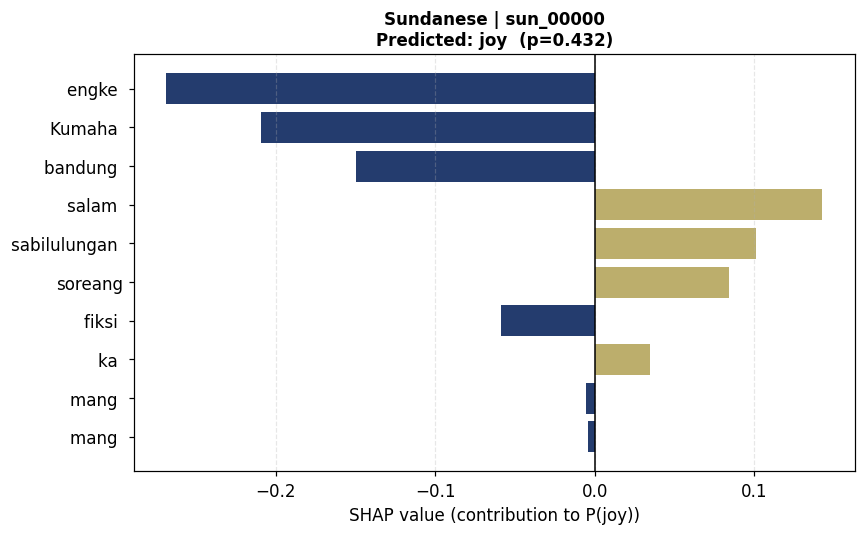

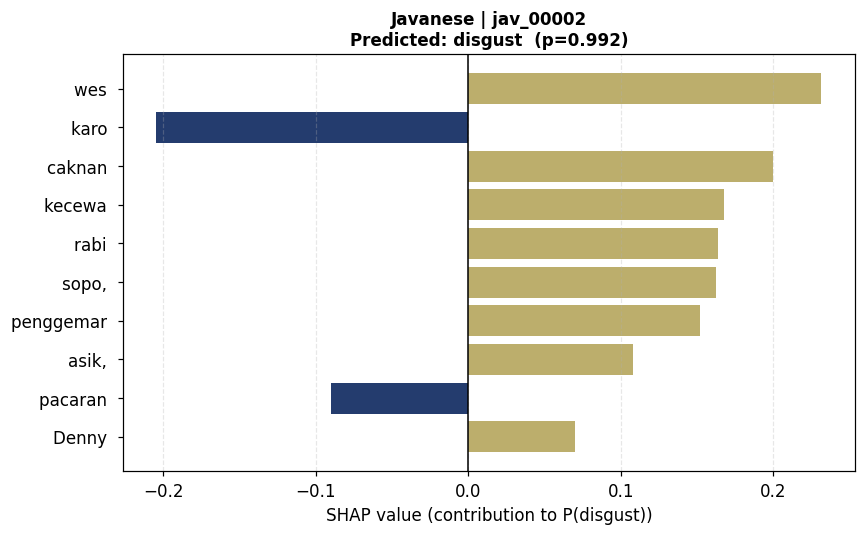

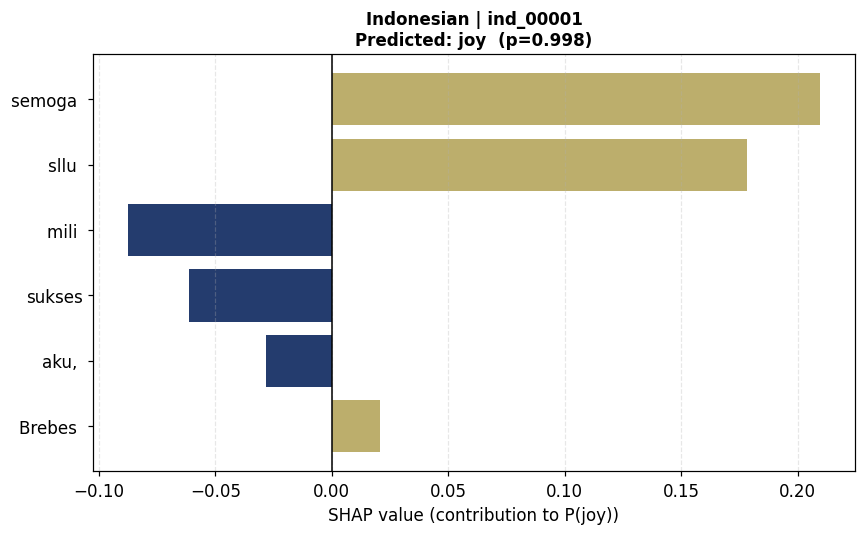

Gambar SHAP disimpan (PNG 600 dpi + PDF) di /content/drive/MyDrive/INASS Project/outputs/Semeval/figures


In [12]:
# ============================================================
# SHAP TOKEN-LEVEL EXPLANATION
# ============================================================
try:
    import shap
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=False)
    import shap


@torch.no_grad()
def embed_texts(texts, batch_size=BATCH_SIZE):
    """Masked mean pooling XLM-R — identik dengan yang dipakai pipeline utama."""
    out = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = xlmr_tok(batch, padding=True, truncation=True,
                       max_length=MAX_LEN, return_tensors="pt").to(device)
        h = xlmr_mod(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1).clamp(min=1e-9)).cpu().numpy())
    return np.vstack(out)


def predict_texts(texts, emotion=None):
    """teks -> probabilitas ensemble. Batched. Rantai penuh, sama seperti pipeline utama."""
    texts = [str(t) for t in np.atleast_1d(np.asarray(texts, dtype=object))]
    Z = transform_ref(embed_texts(texts))
    proba = predict_proba(Z, xgb_ref, lr_ref, CFG_MEXBAL)
    if emotion is None:
        return proba
    return proba[:, EMOTION_COLS.index(emotion)]


masker = shap.maskers.Text(r"\W+")


def explain_text(text, emotion, max_evals=SHAP_MAX_EVALS):
    """Jalankan Partition explainer. max_evals dinaikkan otomatis bila teks panjang,
    karena shap mensyaratkan max_evals > 2 * jumlah_token."""
    n_tok = len(re.findall(r"\S+", str(text)))
    budget = max(max_evals, 2 * n_tok + 2)
    ex = shap.Explainer(lambda x: predict_texts(x, emotion), masker)
    try:
        return ex([text], max_evals=budget)[0]
    except TypeError:                      # versi shap lama: max_evals di konstruktor
        return shap.Explainer(lambda x: predict_texts(x, emotion),
                              masker, max_evals=budget)([text])[0]


shap_samples = []
for lang in LANGS:
    te_idx = SPLITS[(lang, SEED_PRIMARY)][2]
    shap_samples.append((lang, DATA[lang].iloc[te_idx[0]]))

shap_cache = {}
for lang, row in shap_samples:
    text = str(row["text"])
    probs = predict_texts([text])[0]
    pred_emotion = EMOTION_COLS[int(np.argmax(probs))]

    sv = explain_text(text, pred_emotion)
    shap_cache[lang] = {"text": text, "emotion": pred_emotion,
                        "tokens": list(sv.data), "values": np.array(sv.values),
                        "uid": row["uid"], "p": float(probs[EMOTION_COLS.index(pred_emotion)])}

    toks = [(w, v) for w, v in zip(sv.data, sv.values) if str(w).strip()]
    toks_sorted = sorted(toks, key=lambda t: abs(t[1]), reverse=True)[:10]
    words = [t[0] for t in toks_sorted][::-1]
    vals  = [t[1] for t in toks_sorted][::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = [plt.cm.cividis(0.75) if v > 0 else plt.cm.cividis(0.15) for v in vals]
    ax.barh(range(len(words)), vals, color=colors)
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("SHAP value (contribution to P(%s))" % pred_emotion)
    ax.set_title(f"{LANG_LABEL[lang]} | {row['uid']}\nPredicted: {pred_emotion}  (p={shap_cache[lang]['p']:.3f})",
                 fontweight="bold", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    fig.tight_layout()
    savefig(fig, f"shap_{lang}")
    plt.show()

print("Gambar SHAP disimpan (PNG 600 dpi + PDF) di", FIG_DIR)

## 10. SHAP Faithfulness Test — Deletion / Insertion + AOPC

Reviewer 2 #4 requested faithfulness validation, not just a description of the method. This test deletes (or inserts) tokens based on their |SHAP| rank and measures how quickly the prediction probability collapses, then compares it against a **random** token order as a control.

- **AOPC deletion** — higher is better: deleting high-ranked tokens should drop the probability quickly.
- **AOPC insertion** — higher is better: inserting high-ranked tokens into empty text should raise the probability quickly.
- If the SHAP curve is not different from the random curve, the explanation is not faithful, and this must be reported as is.

faithfulness:   0%|          | 0/30 [00:00<?, ?it/s]


TABEL 6 — SHAP FAITHFULNESS (30 sampel test, top-5 token)
                          metric    SHAP ranking   Random ranking  mean_diff  p_value  significant_0.05
 AOPC deletion (higher = better) 0.1604 ± 0.2913  0.0951 ± 0.2577     0.0653   0.1840             False
AOPC insertion (higher = better) 0.1061 ± 0.2813 -0.0438 ± 0.2685     0.1500   0.0185              True

Interpretasi: bila AOPC SHAP > AOPC random secara signifikan, penjelasan token
terbukti faithful terhadap prediksi model — inilah bukti kuantitatif yang diminta
Reviewer 2 #4. Bila tidak signifikan, laporkan apa adanya dan turunkan klaim.


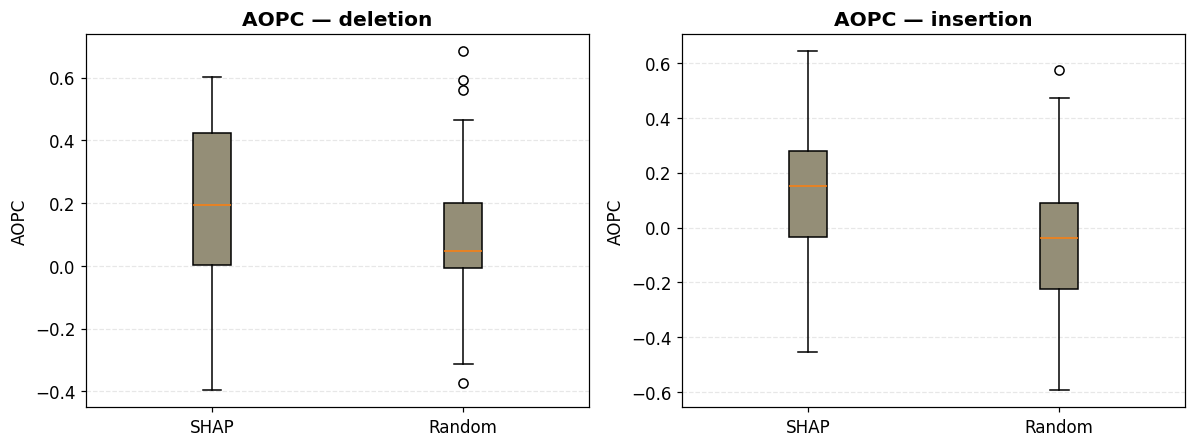

In [13]:
# ============================================================
# FAITHFULNESS: DELETION / INSERTION / AOPC
#
# Unit perturbasi = token milik SHAP itu sendiri (sv.data). Text masker
# menjamin "".join(sv.data) == teks asli, jadi menghapus/menyisipkan token
# dilakukan tepat pada unit yang sama dengan yang diberi nilai atribusi —
# tidak ada masalah alignment antara tokenisasi kita dan tokenisasi shap.
# ============================================================
def perturb_curve(tokens, ranking, k_max, mode, emotion):
    """mode='deletion': buang top-k token. mode='insertion': mulai kosong, sisipkan top-k."""
    variants = []
    for k in range(0, k_max + 1):
        chosen = set(ranking[:k])
        if mode == "deletion":
            parts = ["" if i in chosen else t for i, t in enumerate(tokens)]
        else:
            parts = [t if i in chosen else "" for i, t in enumerate(tokens)]
        variants.append("".join(parts))
    return predict_texts(variants, emotion)


def aopc(scores, mode):
    """Area over the perturbation curve, dinormalisasi terhadap jumlah langkah."""
    if mode == "deletion":
        return float(np.mean([scores[0] - s for s in scores[1:]]))
    return float(np.mean([s - scores[0] for s in scores[1:]]))


if RUN_FAITHFUL:
    rng = np.random.default_rng(SEED_PRIMARY)
    K_MAX = 5

    pool = []
    for lang in LANGS:
        for i in SPLITS[(lang, SEED_PRIMARY)][2]:
            pool.append((lang, DATA[lang].iloc[i]))
    rng.shuffle(pool)
    pool = pool[:N_FAITHFUL]

    rows, skipped = [], 0
    for lang, row in tqdm(pool, desc="faithfulness"):
        text = str(row["text"])
        probs = predict_texts([text])[0]
        emo = EMOTION_COLS[int(np.argmax(probs))]

        try:
            sv = explain_text(text, emo)
        except Exception as e:
            skipped += 1
            continue

        tokens = [str(t) for t in sv.data]
        vals = np.asarray(sv.values, dtype=float).ravel()
        content = [i for i, t in enumerate(tokens) if t.strip() and i < len(vals)]
        if len(content) < 3:
            skipped += 1
            continue

        shap_rank = sorted(content, key=lambda i: -abs(vals[i]))
        rand_rank = list(rng.permutation(content))
        k = min(K_MAX, len(content) - 1)

        rec = {"lang": LANG_LABEL[lang], "uid": row["uid"], "emotion": emo,
               "n_tokens": len(content)}
        for mode in ("deletion", "insertion"):
            rec[f"aopc_{mode}_shap"]   = aopc(perturb_curve(tokens, shap_rank, k, mode, emo), mode)
            rec[f"aopc_{mode}_random"] = aopc(perturb_curve(tokens, rand_rank, k, mode, emo), mode)
        rows.append(rec)

    df_faith = pd.DataFrame(rows)
    df_faith.to_csv(os.path.join(OUT_DIR, "raw_faithfulness_per_sample.csv"), index=False)
    if skipped:
        print(f"({skipped} sampel dilewati: teks terlalu pendek atau explainer gagal)")

    print("\n" + "=" * 82)
    print(f"TABEL 6 — SHAP FAITHFULNESS ({len(df_faith)} sampel test, top-{K_MAX} token)")
    print("=" * 82)
    summ = []
    for mode in ("deletion", "insertion"):
        a = df_faith[f"aopc_{mode}_shap"].values
        b = df_faith[f"aopc_{mode}_random"].values
        try:
            st, p = stats.wilcoxon(a, b)
        except Exception:
            st, p = np.nan, np.nan
        summ.append({
            "metric": f"AOPC {mode} (higher = better)",
            "SHAP ranking": f"{a.mean():.4f} ± {a.std(ddof=1):.4f}",
            "Random ranking": f"{b.mean():.4f} ± {b.std(ddof=1):.4f}",
            "mean_diff": a.mean() - b.mean(),
            "p_value": p,
            "significant_0.05": (p < 0.05) if p == p else False,
        })
    faith_tbl = pd.DataFrame(summ)
    print(faith_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    faith_tbl.to_csv(os.path.join(OUT_DIR, "table6_shap_faithfulness.csv"), index=False)

    print("\nInterpretasi: bila AOPC SHAP > AOPC random secara signifikan, penjelasan token")
    print("terbukti faithful terhadap prediksi model — inilah bukti kuantitatif yang diminta")
    print("Reviewer 2 #4. Bila tidak signifikan, laporkan apa adanya dan turunkan klaim.")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, mode in zip(axes, ("deletion", "insertion")):
        ax.boxplot([df_faith[f"aopc_{mode}_shap"], df_faith[f"aopc_{mode}_random"]],
                   patch_artist=True, boxprops=dict(facecolor=plt.cm.cividis(0.6)))
        ax.set_xticks([1, 2]); ax.set_xticklabels(["SHAP", "Random"])
        ax.set_title(f"AOPC — {mode}", fontweight="bold")
        ax.set_ylabel("AOPC")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    savefig(fig, "shap_faithfulness_aopc")
    plt.show()
else:
    print("RUN_FAITHFUL = False -> dilewati")

## 11. Computational Time Analysis — Separate Boundaries

Reviewers 1 #7 and #8 rejected previous efficiency claims because the measurement boundaries were unclear and inconsistent. Here, each cost component is measured separately, so the manuscript can distinguish between training efficiency, inference efficiency, and the cost of generating explanations—rather than presenting it as a single generic advantage.

All models are measured on the **same** test set (Sundanese, the largest test set), with 20 inference repetitions and standard deviation reported.

warmup:   0%|          | 0/1 [00:00<?, ?it/s]

timing/xlmr:   0%|          | 0/8 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

...

warmup:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

timing/indo:   0%|          | 0/8 [00:00<?, ?it/s]

TABEL 7 — BIAYA KOMPUTASI (test set Sundanese, n=226, inference 20x run)
          Model  Embedding extraction (s)  Preprocessing fit (s)  Classifier training (s)  Threshold search (s)  Total training (s)  Classifier inference (s)  Inference sd (s)  Inference per sample (ms)  End-to-end inference per sample (ms)
        ME-XBAL                  0.825330               1.949179                 0.434384              2.386802            4.770365                  0.006974          0.001470                   0.030860                              3.682764
    ME-XBAL+XGB                  0.825330               1.441727                 8.912491              1.416329           11.770547                  0.014786          0.000605                   0.065426                              3.717330
   XLM-R Hybrid                  0.825330               0.316247                 8.896468              1.458820           10.671535                  0.017694          0.006051                   0.078291  

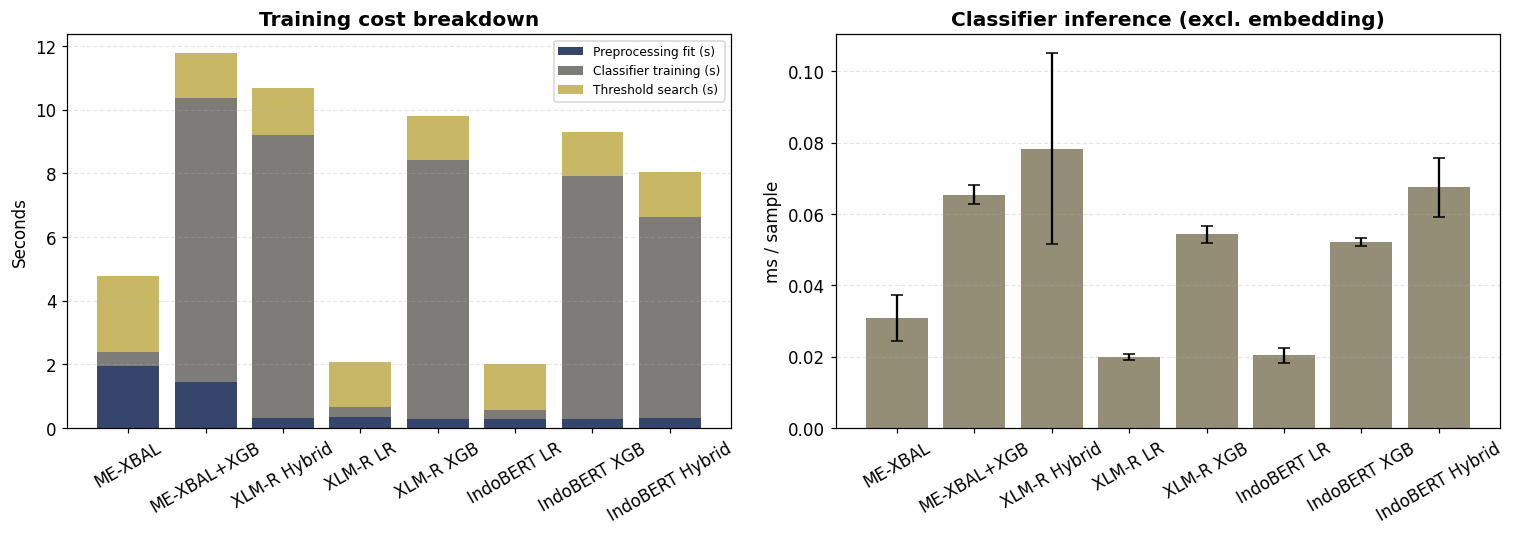

In [14]:
# ============================================================
# TIMING — BOUNDARY DIPISAH
# ============================================================
if RUN_TIMING:
    TIMING_LANG = "sun"          # test set terbesar -> pengukuran paling stabil
    te_idx = SPLITS[(TIMING_LANG, SEED_PRIMARY)][2]
    texts_timing = DATA[TIMING_LANG]["text"].iloc[te_idx].tolist()
    n_timing = len(texts_timing)

    # --- biaya ekstraksi embedding, diukur sekali per encoder ---
    embed_cost = {}
    for key, name in ENCODERS.items():
        tok, mod = (xlmr_tok, xlmr_mod) if key == "xlmr" else load_encoder(name)
        _ = encode_texts(texts_timing[:8], tok, mod, desc="warmup")     # warm-up
        t0 = time.perf_counter()
        _ = encode_texts(texts_timing, tok, mod, desc=f"timing/{key}")
        embed_cost[key] = time.perf_counter() - t0
        if key != "xlmr":
            del mod; torch.cuda.empty_cache()

    rows = []
    for cfg in VARIANTS:
        set_seed(SEED_PRIMARY)
        E = EMB[cfg["encoder"]]
        tr = {l: SPLITS[(l, SEED_PRIMARY)][0] for l in LANGS}
        X_tr = np.vstack([E[l][tr[l]] for l in LANGS])
        y_tr = np.vstack([Y[l][tr[l]] for l in LANGS])

        t0 = time.perf_counter()
        transform, _, _ = build_preprocessor(X_tr, cfg["scale"], cfg["do_pca"], SEED_PRIMARY)
        X_tr_t = transform(X_tr)
        t_preproc = time.perf_counter() - t0

        t0 = time.perf_counter()
        xm, lm = train_classifiers(X_tr_t, y_tr, cfg, SEED_PRIMARY)
        t_train = time.perf_counter() - t0

        va = SPLITS[(TIMING_LANG, SEED_PRIMARY)][1]
        t0 = time.perf_counter()
        if cfg["tune_threshold"]:
            pv = predict_proba(transform(E[TIMING_LANG][va]), xm, lm, cfg)
            th = tune_thresholds(pv, Y[TIMING_LANG][va])
        else:
            th = {e: 0.5 for e in EMOTION_COLS}
        t_thresh = time.perf_counter() - t0

        X_te = E[TIMING_LANG][te_idx]
        _ = predict_proba(transform(X_te), xm, lm, cfg)      # warm-up
        times = []
        for _ in range(20):
            t0 = time.perf_counter()
            p = predict_proba(transform(X_te), xm, lm, cfg)
            _ = apply_thresholds(p, th)
            times.append(time.perf_counter() - t0)
        t_inf, t_inf_sd = float(np.mean(times)), float(np.std(times, ddof=1))

        rows.append({
            "Model": cfg["name"],
            "Embedding extraction (s)": embed_cost[cfg["encoder"]],
            "Preprocessing fit (s)": t_preproc,
            "Classifier training (s)": t_train,
            "Threshold search (s)": t_thresh,
            "Total training (s)": t_preproc + t_train + t_thresh,
            "Classifier inference (s)": t_inf,
            "Inference sd (s)": t_inf_sd,
            "Inference per sample (ms)": 1000 * t_inf / n_timing,
            "End-to-end inference per sample (ms)":
                1000 * (t_inf + embed_cost[cfg["encoder"]]) / n_timing,
        })

    df_time = pd.DataFrame(rows).set_index("Model").loc[VARIANT_ORDER].reset_index()

    # --- biaya menghasilkan penjelasan SHAP (hanya ME-XBAL) ---
    try:
        sample_text = str(DATA[TIMING_LANG]["text"].iloc[te_idx[0]])
        emo = EMOTION_COLS[int(np.argmax(predict_texts([sample_text])[0]))]
        t0 = time.perf_counter()
        _ = explain_text(sample_text, emo)
        shap_cost = time.perf_counter() - t0
    except Exception as e:
        print("SHAP timing dilewati:", e)
        shap_cost = float("nan")

    print("=" * 100)
    print(f"TABEL 7 — BIAYA KOMPUTASI (test set {LANG_LABEL[TIMING_LANG]}, n={n_timing}, "
          f"inference 20x run)")
    print("=" * 100)
    print(df_time.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"\nBiaya penjelasan SHAP (ME-XBAL, max_evals={SHAP_MAX_EVALS}): "
          f"{shap_cost:.3f} s/sampel")
    print("\nCatatan untuk manuskrip: ekstraksi embedding mendominasi total biaya dan")
    print("BESARNYA SAMA untuk semua varian ber-encoder sama. Klaim yang boleh dibuat adalah")
    print("trade-off performa-efisiensi, bukan 'superior computational efficiency'.")

    # Biaya SHAP diukur pada MODEL REFERENSI, jadi atribusinya harus mengikuti
    # MEXBAL_NAME, bukan string "ME-XBAL" yang kini menunjuk varian ringan.
    df_time["SHAP cost per sample (s)"] = [shap_cost if m == MEXBAL_NAME else np.nan
                                           for m in df_time["Model"]]
    df_time.to_csv(os.path.join(OUT_DIR, "table7_computational_cost.csv"), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    comp = ["Preprocessing fit (s)", "Classifier training (s)", "Threshold search (s)"]
    bottom = np.zeros(len(df_time))
    for j, c in enumerate(comp):
        axes[0].bar(df_time["Model"], df_time[c], bottom=bottom,
                    label=c, color=plt.cm.cividis(0.2 + 0.3 * j))
        bottom += df_time[c].values
    axes[0].set_ylabel("Seconds"); axes[0].set_title("Training cost breakdown", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30); axes[0].legend(fontsize=8)

    axes[1].bar(df_time["Model"], df_time["Inference per sample (ms)"],
                yerr=1000 * df_time["Inference sd (s)"] / n_timing,
                capsize=4, color=plt.cm.cividis(0.6))
    axes[1].set_ylabel("ms / sample")
    axes[1].set_title("Classifier inference (excl. embedding)", fontweight="bold")
    axes[1].tick_params(axis="x", rotation=30)
    for ax in axes:
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    savefig(fig, "computational_cost")
    plt.show()
else:
    print("RUN_TIMING = False -> dilewati")

## 12. Baselines Outside Frozen Embeddings — Fine-tuned XLM-R (Optional)

Reviewer 1 #9 and Reviewer 2 #1 both rejected the manuscript because all baselines were internal combinations of the same components. This cell adds a **different class** of comparator: XLM-RoBERTa fully fine-tuned with a multi-label classification head (BCE), treated with the exact same protocol—thresholds are still tuned on validation.

This does not yet cover all reviewer requests (LaBSE / multilingual-E5, CatBoost, focal loss, and official SemEval baselines are still needed), but it is the single most frequently asked comparator and the hardest to argue against if absent.

In [15]:
# ============================================================
# BASELINE: FINE-TUNED XLM-R (MULTI-LABEL)
# ============================================================
if RUN_FINETUNE:
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoModelForSequenceClassification

    FT_LR, FT_BS = 2e-5, 16

    class MLDataset(Dataset):
        def __init__(self, texts, labels, tok):
            self.enc = tok([str(t) for t in texts], padding="max_length", truncation=True,
                           max_length=MAX_LEN, return_tensors="pt")
            self.labels = torch.tensor(labels, dtype=torch.float)
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: v[i] for k, v in self.enc.items()}
            item["labels"] = self.labels[i]
            return item

    @torch.no_grad()
    def ft_predict(model, texts, tok):
        model.eval()
        out = []
        for i in range(0, len(texts), 32):
            enc = tok([str(t) for t in texts[i:i+32]], padding=True, truncation=True,
                      max_length=MAX_LEN, return_tensors="pt").to(device)
            out.append(torch.sigmoid(model(**enc).logits).cpu().numpy())
        return np.vstack(out)

    ft_records = []
    for seed in FT_SEEDS:
        set_seed(seed)
        tok = AutoTokenizer.from_pretrained(XLMR_NAME)
        model_ft = AutoModelForSequenceClassification.from_pretrained(
            XLMR_NAME, num_labels=len(EMOTION_COLS),
            problem_type="multi_label_classification").to(device)

        tr_idx = {l: SPLITS[(l, seed)][0] for l in LANGS}
        texts_tr = sum([DATA[l]["text"].iloc[tr_idx[l]].tolist() for l in LANGS], [])
        y_tr = np.vstack([Y[l][tr_idx[l]] for l in LANGS])

        dl = DataLoader(MLDataset(texts_tr, y_tr, tok), batch_size=FT_BS, shuffle=True)
        opt = torch.optim.AdamW(model_ft.parameters(), lr=FT_LR)

        # ------------------------------------------------------------
        # EARLY STOPPING pada Macro F1 validation.
        # Tanpa ini, fine-tuning pada data sekecil ini menghasilkan variansi
        # besar antar seed (std 0.059-0.072 pada run sebelumnya), yang membuat
        # uji berpasangan kehilangan daya. Perbandingan menjadi lebih adil:
        # pipeline klasik memakai train+validation lewat nested CV, fine-tuning
        # memakai train untuk melatih dan validation untuk menghentikan —
        # keduanya melihat himpunan data yang sama.
        # ------------------------------------------------------------
        val_texts = sum([DATA[l]["text"].iloc[SPLITS[(l, seed)][1]].tolist()
                         for l in LANGS], [])
        y_val_ft = np.vstack([Y[l][SPLITS[(l, seed)][1]] for l in LANGS])

        # ------------------------------------------------------------
        # WALL-CLOCK FINE-TUNING
        #
        # Boundary training fine-tuning = seluruh loop epoch termasuk early stopping,
        # TIDAK termasuk pemuatan tokenizer/checkpoint. Ini tidak identik dengan
        # boundary "total train" pipeline beku (preprocessing + classifier + threshold,
        # dengan ekstraksi embedding dilaporkan terpisah), karena fine-tuning tidak
        # memiliki tahap embedding yang terpisah. Perbedaan boundary ini harus
        # dinyatakan di catatan tabel manuskrip, bukan disembunyikan.
        #
        # Inference diukur pada seluruh test set setelah warm-up, dilaporkan per sampel.
        # ------------------------------------------------------------
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t_train0 = time.perf_counter()

        best_f1, best_state, patience_left = -1.0, None, FT_PATIENCE
        for ep in range(FT_MAX_EPOCHS):
            model_ft.train()
            tot = 0.0
            for batch in tqdm(dl, desc=f"FT seed={seed} ep{ep+1}/{FT_MAX_EPOCHS}", leave=False):
                batch = {k: v.to(device) for k, v in batch.items()}
                opt.zero_grad()
                loss = model_ft(**batch).loss
                loss.backward(); opt.step()
                tot += loss.item()

            pv = ft_predict(model_ft, val_texts, tok)
            th_val = tune_thresholds(pv, y_val_ft)
            f1_val = f1_score(y_val_ft, apply_thresholds(pv, th_val),
                              average="macro", zero_division=0)
            print(f"  seed={seed} epoch {ep+1}: loss {tot/len(dl):.4f}  val macro F1 {f1_val:.4f}")

            if f1_val > best_f1 + 1e-6:
                best_f1 = f1_val
                best_state = {k: v.detach().cpu().clone() for k, v in model_ft.state_dict().items()}
                patience_left = FT_PATIENCE
            else:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"  seed={seed}: early stop di epoch {ep+1} "
                          f"(val macro F1 terbaik {best_f1:.4f})")
                    break

        if best_state is not None:
            model_ft.load_state_dict(best_state)

        if torch.cuda.is_available(): torch.cuda.synchronize()
        ft_train_time = time.perf_counter() - t_train0

        rec = {"cfg": "XLM-R fine-tuned", "seed": seed, "setting": "S1",
               "train_time_s": ft_train_time}
        for l in LANGS:
            va, te = SPLITS[(l, seed)][1], SPLITS[(l, seed)][2]
            pv = ft_predict(model_ft, DATA[l]["text"].iloc[va].tolist(), tok)
            th = tune_thresholds(pv, Y[l][va])                 # tetap di validation
            pt = ft_predict(model_ft, DATA[l]["text"].iloc[te].tolist(), tok)
            pred = apply_thresholds(pt, th)
            rec[f"macro_f1_{l}"] = f1_score(Y[l][te], pred, average="macro", zero_division=0)
            rec[f"micro_f1_{l}"] = f1_score(Y[l][te], pred, average="micro", zero_division=0)
        texts_te_all = sum([DATA[l]["text"].iloc[SPLITS[(l, seed)][2]].tolist()
                            for l in LANGS], [])
        _ = ft_predict(model_ft, texts_te_all[:8], tok)              # warm-up
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t_inf0 = time.perf_counter()
        _ = ft_predict(model_ft, texts_te_all, tok)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        rec["infer_ms_per_sample"] = (time.perf_counter() - t_inf0) / len(texts_te_all) * 1000
        print(f"  seed={seed} biaya: train {ft_train_time:.1f}s | "
              f"inference {rec['infer_ms_per_sample']:.4f} ms/sampel")

        ft_records.append(rec)
        print(f"  seed={seed} -> " + "  ".join(
            f"{LANG_LABEL[l]}:{rec[f'macro_f1_{l}']:.4f}" for l in LANGS))

        del model_ft; torch.cuda.empty_cache()

    df_ft = pd.DataFrame(ft_records)
    df_ft.to_csv(os.path.join(OUT_DIR, "raw_results_finetuned_xlmr.csv"), index=False)

    sub = df_s1[(df_s1["cfg"] == "ME-XBAL") & (df_s1["seed"].isin(FT_SEEDS))]
    sub_xgb = df_s1[(df_s1["cfg"] == "ME-XBAL+XGB") & (df_s1["seed"].isin(FT_SEEDS))]
    comp = pd.concat([sub[["cfg", "seed"] + macro_cols],
                      sub_xgb[["cfg", "seed"] + macro_cols],
                      df_ft[["cfg", "seed"] + macro_cols]])
    summ_ft = summarize(comp, macro_cols)

    print("\n" + "=" * 78)
    print(f"TABEL 8 — PEMBANDING FINE-TUNED (mean ± std atas {len(FT_SEEDS)} seed)")
    print("=" * 78)
    v = summ_ft[["cfg"] + [f"macro_f1_{l}_str" for l in LANGS]]
    v.columns = ["Model"] + [LANG_LABEL[l] for l in LANGS]
    print(v.to_string(index=False))

    # ------------------------------------------------------------
    # UJI SIGNIFIKANSI vs FINE-TUNED
    # ------------------------------------------------------------
    ft_rows = []
    ref = df_ft.sort_values("seed")
    for name, frame in [("ME-XBAL", sub), ("ME-XBAL+XGB", sub_xgb)]:
        g = frame.sort_values("seed")
        for l in LANGS + ["avg"]:
            if l == "avg":
                a = g[macro_cols].mean(axis=1).values
                b = ref[macro_cols].mean(axis=1).values
                lang_label = "Average"
            else:
                a = g[f"macro_f1_{l}"].values
                b = ref[f"macro_f1_{l}"].values
                lang_label = LANG_LABEL[l]
            try:
                _, p = stats.wilcoxon(a, b)
            except Exception:
                p = np.nan
            pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
            ft_rows.append({"comparison": f"{name} vs XLM-R fine-tuned", "language": lang_label,
                            "mean_diff": a.mean() - b.mean(),
                            "cohens_d": (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan,
                            "p_value": p,
                            "significant_0.05": (p < 0.05) if p == p else False})
    ft_sig = pd.DataFrame(ft_rows)
    print("\nUJI SIGNIFIKANSI vs FINE-TUNED (Wilcoxon berpasangan atas seed)")
    print(ft_sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    if len(FT_SEEDS) < 6:
        print(f"\nPERINGATAN: hanya {len(FT_SEEDS)} seed. Wilcoxon berpasangan tidak dapat "
              "mencapai p < 0.05 dengan n sekecil ini (p minimum = 0.25 untuk n=3).")
        print("Naikkan FT_SEEDS ke seluruh SEEDS sebelum mengklaim apa pun dari tabel ini.")
    else:
        wins = ft_sig[ft_sig["significant_0.05"] & (ft_sig["mean_diff"] > 0)]
        if len(wins):
            print("\nHasil yang bisa diklaim di manuskrip:")
            for _, r in wins.iterrows():
                print(f"  - {r['comparison']} pada {r['language']}: "
                      f"+{r['mean_diff']:.4f} (p={r['p_value']:.4f})")
            print("  Pipeline embedding beku mengungguli fine-tuning penuh — ini klaim")
            print("  terkuat yang tersedia, dan biaya trainingnya jauh lebih rendah.")

    summ_ft.to_csv(os.path.join(OUT_DIR, "table8_finetuned_comparison.csv"), index=False)
    ft_sig.to_csv(os.path.join(OUT_DIR, "table8b_finetuned_significance.csv"), index=False)
    print("\nMasih perlu ditambahkan untuk menutup R1#9 / R2#1: LaBSE atau multilingual-E5,")
    print("CatBoost / focal loss, dan skor baseline resmi SemEval-2025 Task 11 per bahasa.")
else:
    print("RUN_FINETUNE = False -> dilewati")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FT seed=42 ep1/8:   0%|          | 0/58 [00:00<?, ?it/s]

  seed=42 epoch 1: loss 0.5029  val macro F1 0.2778


FT seed=42 ep2/8:   0%|          | 0/58 [00:00<?, ?it/s]

...

  seed=606 epoch 6: loss 0.4076  val macro F1 0.4731


FT seed=606 ep7/8:   0%|          | 0/58 [00:00<?, ?it/s]

  seed=606 epoch 7: loss 0.3739  val macro F1 0.3908


FT seed=606 ep8/8:   0%|          | 0/58 [00:00<?, ?it/s]

  seed=606 epoch 8: loss 0.3572  val macro F1 0.4734
  seed=606 -> Sundanese:0.3786  Javanese:0.3799  Indonesian:0.4069

TABEL 8 — PEMBANDING FINE-TUNED (mean ± std atas 10 seed)
           Model       Sundanese        Javanese      Indonesian
         ME-XBAL 0.3933 ± 0.0268 0.4063 ± 0.0310 0.4239 ± 0.0542
     ME-XBAL+XGB 0.3964 ± 0.0238 0.4147 ± 0.0459 0.4495 ± 0.0574
XLM-R fine-tuned 0.3580 ± 0.0638 0.3154 ± 0.0500 0.4156 ± 0.0590

UJI SIGNIFIKANSI vs FINE-TUNED (Wilcoxon berpasangan atas seed)
                     comparison   language  mean_diff  cohens_d  p_value  significant_0.05
    ME-XBAL vs XLM-R fine-tuned  Sundanese     0.0353    0.7210   0.2324             False
    ME-XBAL vs XLM-R fine-tuned   Javanese     0.0909    2.1866   0.0020              True
    ME-XBAL vs XLM-R fine-tuned Indonesian     0.0083    0.1466   0.8457             False
    ME-XBAL vs XLM-R fine-tuned    Average     0.0448    1.1046   0.0020              True
ME-XBAL+XGB vs XLM-R fine-tuned  Sundanes

## 12b. Biaya wall-clock fine-tuning


In [ ]:
# ============================================================
# BIAYA FINE-TUNING vs PIPELINE BEKU
#
# Angka inilah yang menopang argumen trade-off di manuskrip: pada SemEval
# ME-XBAL menang skor DAN jauh lebih murah; pada Tokopedia ME-XBAL kalah skor,
# sehingga selisih biaya menjadi satu-satunya penyeimbang yang tersisa.
# Tanpa angka ini, kekalahan di Tokopedia berdiri tanpa pembanding.
# ============================================================
if RUN_FINETUNE and len(ft_records):
    cost_ft = pd.DataFrame([{"seed": r["seed"],
                             "train_time_s": r.get("train_time_s", np.nan),
                             "infer_ms_per_sample": r.get("infer_ms_per_sample", np.nan)}
                            for r in ft_records])
    summary_ft_cost = pd.DataFrame([{
        "model": "XLM-R fine-tuned (end-to-end)",
        "train_time_s_mean": cost_ft["train_time_s"].mean(),
        "train_time_s_std":  cost_ft["train_time_s"].std(ddof=1),
        "infer_ms_per_sample_mean": cost_ft["infer_ms_per_sample"].mean(),
        "n_seeds": len(cost_ft),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    }])
    cost_ft.to_csv(os.path.join(OUT_DIR, "raw_finetuned_cost_per_seed.csv"), index=False)
    summary_ft_cost.to_csv(os.path.join(OUT_DIR, "table_finetuned_cost.csv"), index=False)

    print("=" * 74)
    print("BIAYA FINE-TUNING XLM-R")
    print("=" * 74)
    print(summary_ft_cost.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    try:
        mex_total = float(df_time.loc[df_time["Model"] == MEXBAL_NAME,
                                      "Total training (s)"].iloc[0])
        ratio = summary_ft_cost["train_time_s_mean"].iloc[0] / mex_total
        print(f"\n{MEXBAL_NAME} total train : {mex_total:.2f} s")
        print(f"Fine-tuning lebih lambat  : {ratio:.1f}x")
    except Exception as e:
        print(f"\n(Rasio terhadap ME-XBAL dilewati: {type(e).__name__} — "
              "cocokkan nama kolom tabel timing bila perlu.)")
else:
    print("RUN_FINETUNE = False atau ft_records kosong -> dilewati")


## 13. Gambar & ekspor akhir

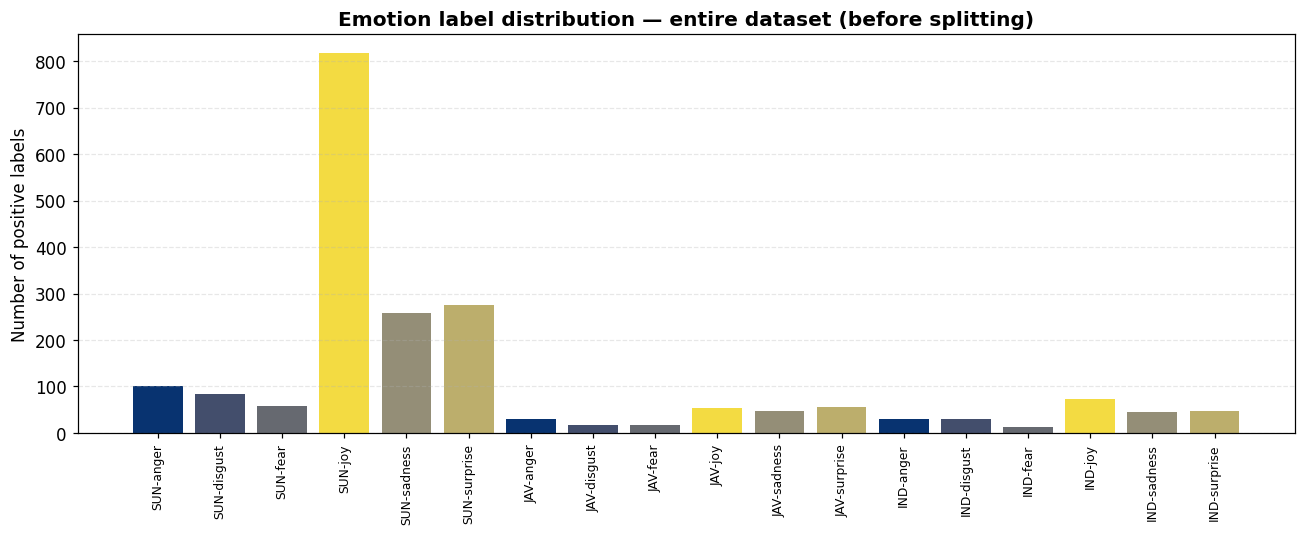

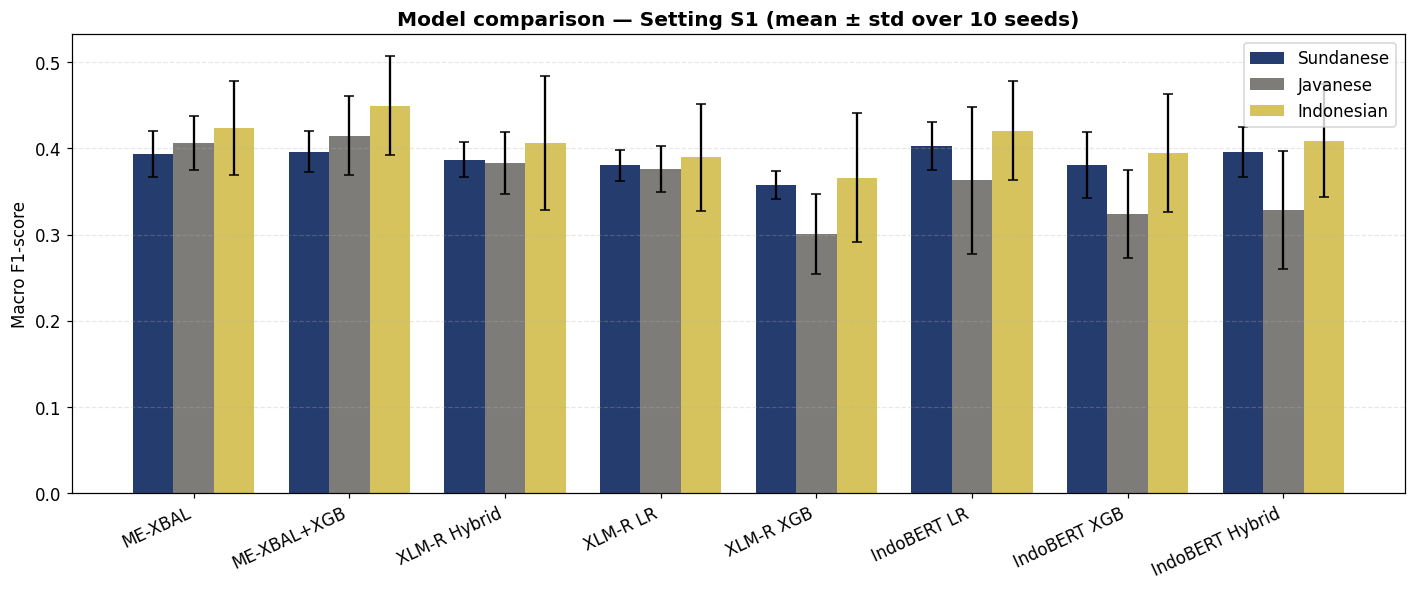

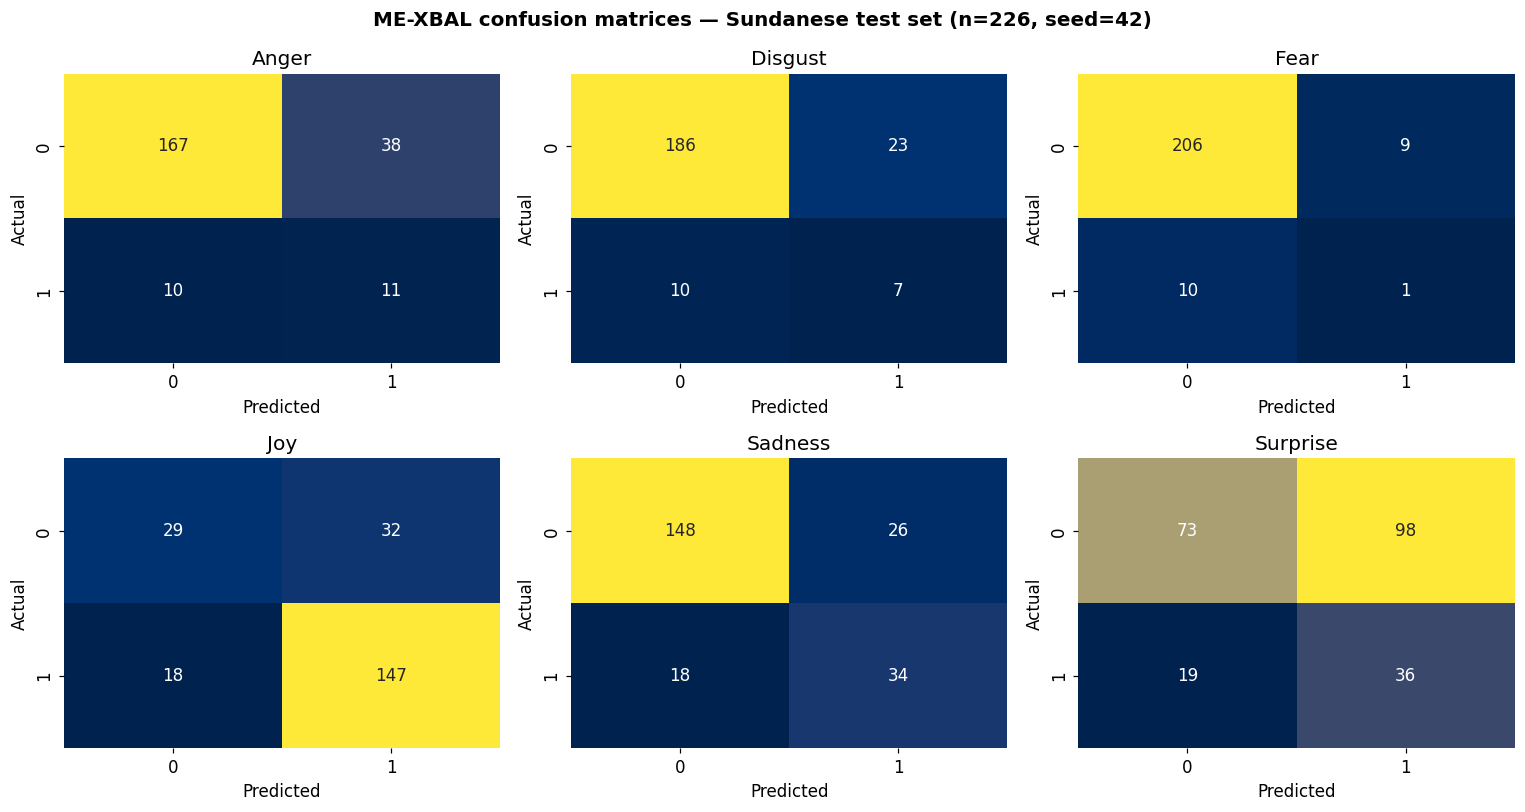

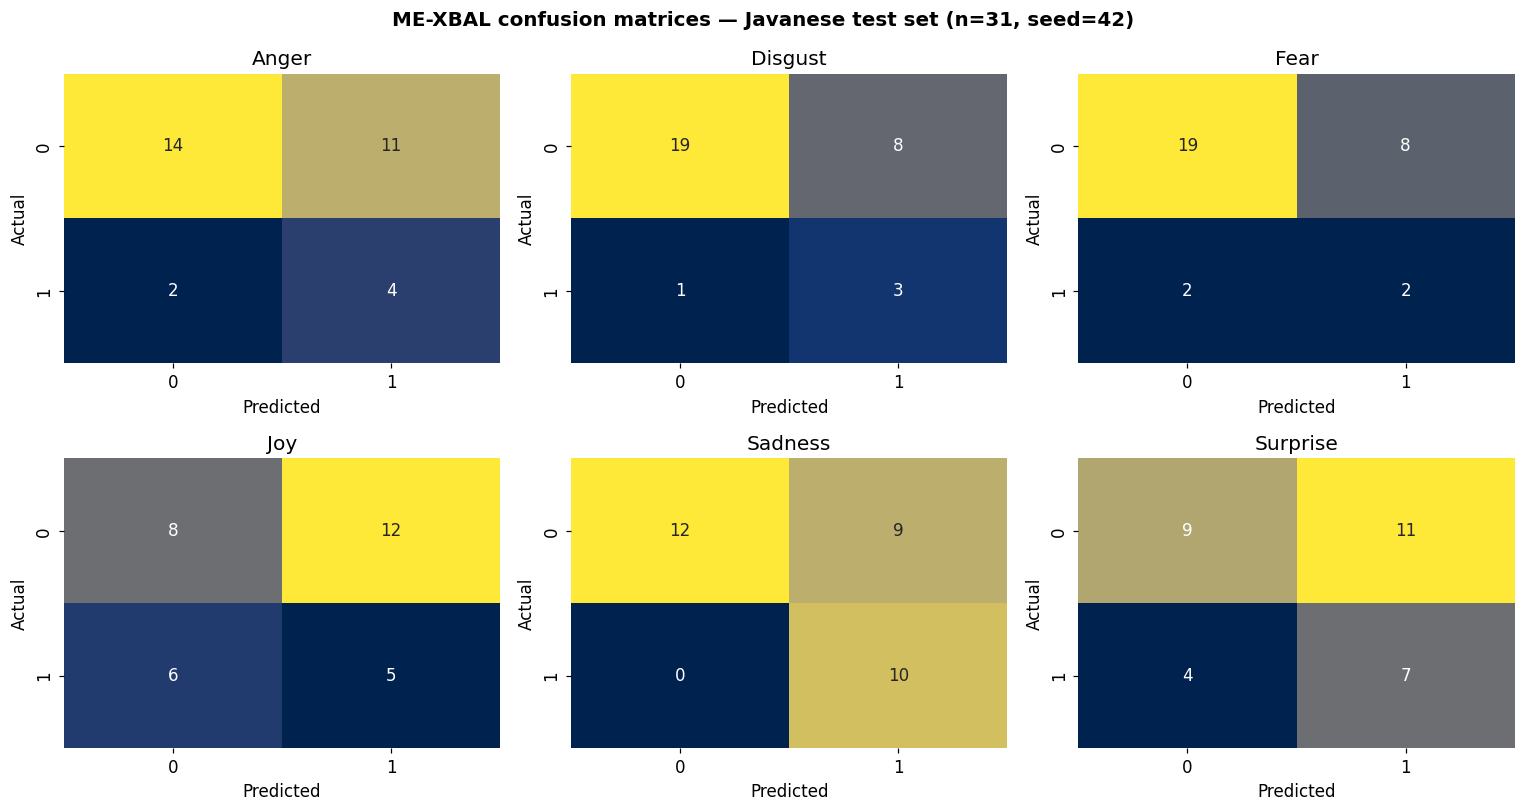

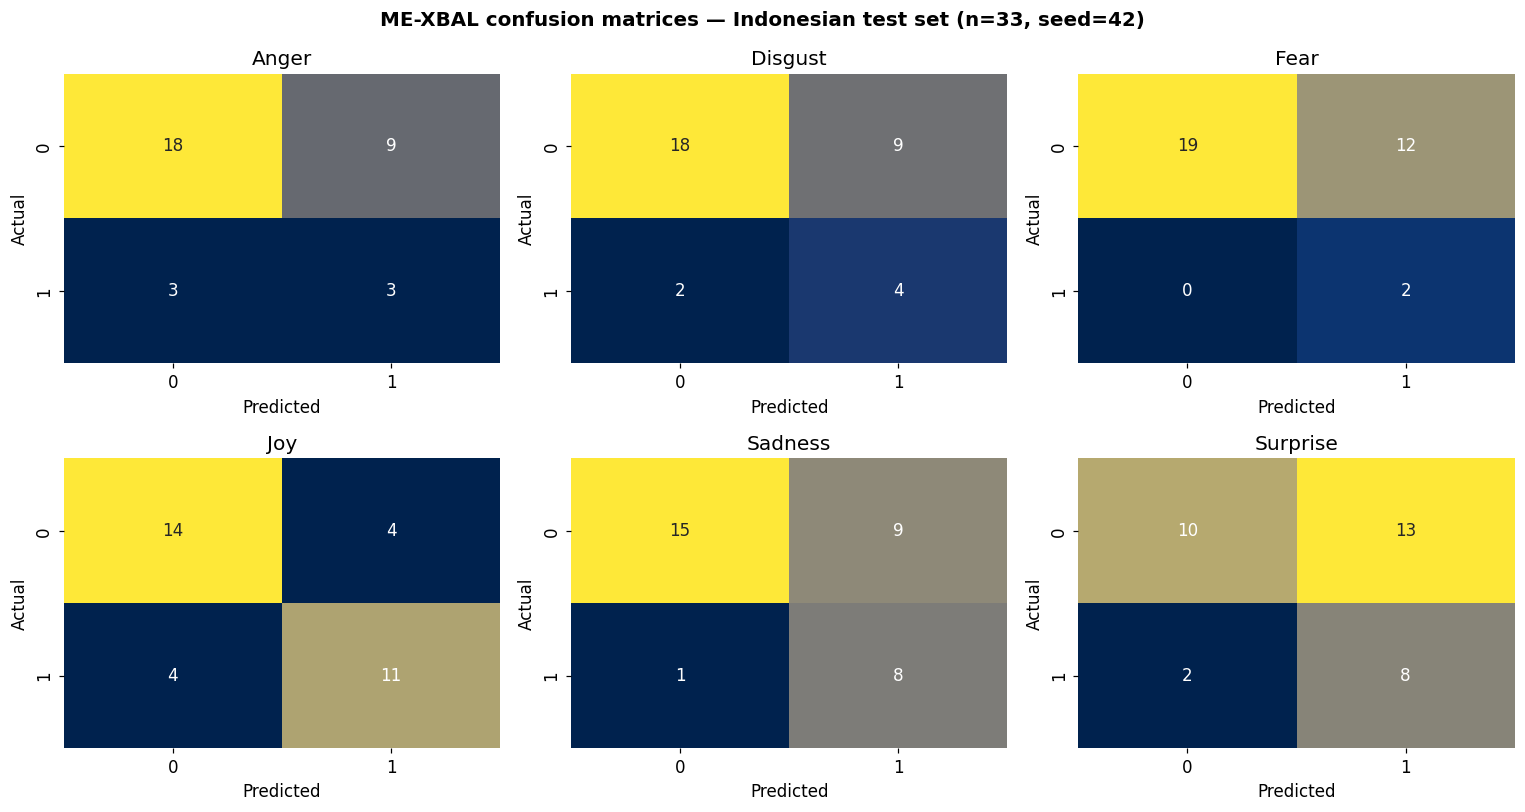

TABEL KONFIGURASI (Appendix)
                    Item                                                                                                                                                                                                                                                       Value
      Encoder (proposed)                                                                                                                                                                                                xlm-roberta-base — frozen, cached embeddings, no fine-tuning
      Encoder (baseline)                                                                                                                                                                                                     indobenchmark/indobert-base-p1 — frozen, own scaler/PCA
        Sentence pooling                                                                                                                    

In [16]:
# ============================================================
# GAMBAR: DISTRIBUSI KELAS, PERBANDINGAN MODEL, CONFUSION MATRIX
# ============================================================
# --- distribusi kelas emosi (seluruh dataset, dinyatakan eksplisit di caption) ---
fig, ax = plt.subplots(figsize=(12, 5))
labels, values, colors = [], [], []
emo_color = {e: plt.cm.cividis(v) for e, v in
             zip(EMOTION_COLS, [0.10, 0.25, 0.40, 0.95, 0.60, 0.75])}
for lang in LANGS:
    counts = DATA[lang][EMOTION_COLS].sum().values
    for e, c in zip(EMOTION_COLS, counts):
        labels.append(f"{lang.upper()}-{e}"); values.append(c); colors.append(emo_color[e])
ax.bar(range(len(values)), values, color=colors)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel("Number of positive labels")
ax.set_title("Emotion label distribution — entire dataset (before splitting)", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout(); savefig(fig, "class_distribution"); plt.show()

# --- perbandingan model dengan error bar dari multi-seed ---
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(VARIANT_ORDER)); w = 0.26
for j, l in enumerate(LANGS):
    m = summary_s1[f"macro_f1_{l}_mean"].values
    e = summary_s1[f"macro_f1_{l}_std"].values
    ax.bar(x + (j - 1) * w, m, w, yerr=e, capsize=3,
           label=LANG_LABEL[l], color=plt.cm.cividis(0.15 + 0.35 * j))
ax.set_xticks(x); ax.set_xticklabels(VARIANT_ORDER, rotation=25, ha="right")
ax.set_ylabel("Macro F1-score")
ax.set_title(f"Model comparison — Setting S1 (mean ± std over {len(SEEDS)} seeds)",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout(); savefig(fig, "model_comparison_S1"); plt.show()

# --- confusion matrix per emosi, ME-XBAL seed utama ---
for lang in LANGS:
    y_true, y_pred = ART["preds"][lang]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
    for i, (e, axx) in enumerate(zip(EMOTION_COLS, axes.flatten())):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap="cividis", cbar=False, ax=axx)
        axx.set_title(e.capitalize()); axx.set_xlabel("Predicted"); axx.set_ylabel("Actual")
    fig.suptitle(f"ME-XBAL confusion matrices — {LANG_LABEL[lang]} test set "
                 f"(n={len(y_true)}, seed={SEED_PRIMARY})", fontweight="bold", fontsize=13)
    fig.tight_layout(); savefig(fig, f"confusion_{lang}"); plt.show()


# ============================================================
# TABEL KONFIGURASI (Appendix, untuk R2#5)
# ============================================================
import sklearn, transformers
try:
    import shap as _shap; shap_ver = _shap.__version__
except Exception:
    shap_ver = "n/a"

config_table = pd.DataFrame([
    ("Encoder (proposed)", XLMR_NAME + " — frozen, cached embeddings, no fine-tuning"),
    ("Encoder (baseline)", INDOBERT_NAME + " — frozen, own scaler/PCA"),
    ("Sentence pooling", "masked mean pooling over last_hidden_state"),
    ("Max sequence length", str(MAX_LEN)),
    ("Dimensionality reduction", "PCA, n_components=0.95 (fit on train only)"),
    ("Feature scaling", "StandardScaler (fit on train only)"),
    ("XGBoost", json.dumps(XGB_PARAMS)),
    ("Cost sensitivity", "scale_pos_weight = n_neg / n_pos, computed on train only"),
    ("Logistic Regression", "C=0.1, L2, lbfgs, max_iter=1000, class_weight=balanced"),
    ("Ensemble weights", f"XGB {CFG_MEXBAL['w_xgb']:.2f} / LR {1-CFG_MEXBAL['w_xgb']:.2f}"),
    ("Threshold grid", f"{THRESHOLD_GRID[0]:.2f}–{THRESHOLD_GRID[-1]:.2f} step 0.01, tuned on validation"),
    ("Split", f"train {1-VAL_FRAC-TEST_FRAC:.2f} / val {VAL_FRAC:.2f} / test {TEST_FRAC:.2f}, "
              "MultilabelStratifiedShuffleSplit"),
    ("Seeds", str(SEEDS)),
    ("Significance test", "Wilcoxon signed-rank over seeds, alpha=0.05"),
    ("SHAP", f"Partition explainer, Text masker r'\\W+', max_evals={SHAP_MAX_EVALS}, "
             "explained function = ensemble probability before thresholding"),
    ("Python", sys.version.split()[0]),
    ("torch", torch.__version__),
    ("transformers", transformers.__version__),
    ("scikit-learn", sklearn.__version__),
    ("xgboost", xgb.__version__),
    ("shap", shap_ver),
    ("numpy", np.__version__),
    ("pandas", pd.__version__),
], columns=["Item", "Value"])
config_table.to_csv(os.path.join(OUT_DIR, "table_appendix_configuration.csv"), index=False)

print("=" * 78)
print("TABEL KONFIGURASI (Appendix)")
print("=" * 78)
print(config_table.to_string(index=False))

print("\n" + "=" * 78)
print("FILE YANG DIHASILKAN")
print("=" * 78)
for root, _, files in os.walk(OUT_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"  {p}  ({os.path.getsize(p)/1024:.1f} KB)")

print("\nSemua tabel manuskrip berasal dari file CSV di atas — satu sumber, tidak ada")
print("angka yang diketik ulang. Kalau ada sel yang dijalankan ulang, regenerasi CSV-nya")
print("dan salin ulang ke manuskrip agar tidak terjadi lagi ketidakcocokan seperti")
print("0.5569 vs 0.5821 di versi sebelumnya.")